# Operational Forecasting System for Onset-Cessation-LGP -- Ethiopia

## ETHIOPIA KIREMT FORECAST PIPELINE  v1.0.0

**Domain:** Ethiopia
**Season:** Kiremt (Main Rains, June-September; forecast window May 2 - Oct 31)
**Forecast source:** Bias-corrected (Quantile Delta Mapping) seasonal ensemble, May-1 initialisation
**Observational reference:** CHIRPS daily precipitation (Ethiopia clip)
**Calibration period:** 1993 - 2016 (24 years)
**Validation period:** 2017 - 2025 (9 years)
**Operational year:** 2026

This notebook follows the same Dunning et al. (2016) detection method as the
Kenya MAM pipeline (`onset-cessation-lgp_v3_dunning_SEAS5_FINAL.ipynb`), but:

- imports the detection/climatology/skill functions from **`dunning_lib.py`**
  (extracted, vectorized, and cross-validated against the original Kenya
  notebook's scalar per-pixel loops -- see that module's docstring for the
  full list of numerical differences, all disclosed and tested) instead of
  redefining them inline, so a bug fix here benefits every notebook that
  imports the library instead of needing to be copy-pasted N times;
- **skips bias correction entirely** -- the seasonal ensemble was already
  bias-corrected upstream via Quantile Delta Mapping and is ingested directly
  from `data/bias-corrected/`, removing what was the single biggest
  performance bottleneck in the Kenya pipeline (member-wise empirical QM,
  ~174M scalar `interp` calls);
- uses **25 ensemble members** for both the historical hindcast (trimmed
  from 51) and the 2026 operational forecast, per an explicit decision to
  keep the two periods directly comparable;
- assigns the **quality-flag layer** (`FLAG_VALID` / `FLAG_NO_ONSET` /
  `FLAG_NO_CESSATION` / `FLAG_SHORT_SEASON`) that the Kenya notebook defined
  but never actually populated (every failure mode there collapsed into an
  undifferentiated NaN).

### Reference
Dunning, C.M., Black, E.C.L., & Allan, R.P. (2016). The onset and cessation
of seasonal rainfall over Africa. *Journal of Geophysical Research:
Atmospheres*, 121(19), 11,405-11,424. https://doi.org/10.1002/2016JD025428


> **Note (added after initial development)**: a critical inverted-scoring-rule bug in `rps_batch` was found and fixed partway through this notebook's development -- see the callout immediately before Stage 8 for details. All RPSS/alpha*/hit-rate numbers reflect the corrected formula.

## IMPORTS AND CONFIGURATION

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import load_dotenv

sys.path.insert(0, os.getcwd())   # so `import dunning_lib` finds it when this
                                   # notebook is run from the notebook/ folder
import dunning_lib as dl

t0 = time.time()
print("Imports OK")


Imports OK


## CONFIGURATION VARIABLES

Paths are resolved from `DATA_DIR` in the repo's `.env` (the same variable
the FastAPI backend uses via `mam_loader.configure()`), not hardcoded
absolute paths -- so this notebook runs on any machine that has `.env`
pointed at its own data root.

In [2]:
load_dotenv(os.path.join("..", ".env"))
DATA_DIR = os.environ.get("DATA_DIR", os.path.join("..", "data"))

COUNTRY, SEASON = "Ethiopia", "Kiremt"

CHIRPS_ET_PATH = os.path.join(DATA_DIR, "chirps_pr_et", "et_chirps_pr_r25_1993_2025.nc")
HINDCAST_PATH  = os.path.join(DATA_DIR, "bias-corrected", "corrected_1993_2025.nc")
FORECAST_PATH  = os.path.join(DATA_DIR, "bias-corrected", "corrected_2026.nc")
ETH_SHP        = os.path.join(DATA_DIR, "shapefiles", "eth", "eth_admin0.shp")

OUT_DIR   = os.path.join(DATA_DIR, "outputs_ETHIOPIA_KIREMT_v1")
CALIB_DIR = os.path.join(OUT_DIR, "calibration_params")
for _d in [OUT_DIR, CALIB_DIR]:
    os.makedirs(_d, exist_ok=True)

# Use the SAME ensemble size for the hindcast and the operational forecast so
# the two periods are directly comparable (hindcast file ships 51 members,
# forecast file ships 25 -- both are trimmed/read to N_MEMBERS here).
N_MEMBERS = 25

CAL_YEARS = np.arange(1993, 2017)    # 1993-2016 (24 yrs) -- CHIRPS ET only goes back to 1993
VAL_YEARS = np.arange(2017, 2026)    # 2017-2025 (9 yrs)  -- same validation window as Kenya MAM
OP_YEAR   = 2026
ALL_YEARS = np.concatenate([CAL_YEARS, VAL_YEARS, [OP_YEAR]])

# Kiremt forecast window: fixed by the bias-corrected files' own coverage
# (May 2 - Oct 31, 183 days per year) -- CHIRPS climatology must use the
# identical window so observations and forecasts are detected consistently.
WIN_DOY_START, WIN_DOY_END = 122, 304
DUNNING_BUFFER_DAYS = 50      # same buffer as Kenya MAM around d_s/d_e
MIN_LGP_DAYS        = 20      # seasons shorter than this -> FLAG_SHORT_SEASON
MIN_TERCILE_YEARS   = 12      # pixels below this -> domain-median tercile fallback
ALPHA_GRID = np.round(np.arange(0.0, 1.01, 0.01), 2)

print(f"{COUNTRY} {SEASON} pipeline")
print(f"  CAL {CAL_YEARS[0]}-{CAL_YEARS[-1]} ({len(CAL_YEARS)}y)   "
      f"VAL {VAL_YEARS[0]}-{VAL_YEARS[-1]} ({len(VAL_YEARS)}y)   OP {OP_YEAR}")
print(f"  Members: {N_MEMBERS}   Window: DOY {WIN_DOY_START}-{WIN_DOY_END}   "
      f"Buffer: {DUNNING_BUFFER_DAYS}d")


Ethiopia Kiremt pipeline
  CAL 1993-2016 (24y)   VAL 2017-2025 (9y)   OP 2026
  Members: 25   Window: DOY 122-304   Buffer: 50d


## STAGE 1: CHIRPS ET INGESTION

Reshapes the flat daily time axis into `(year, doy, lat, lon)` and builds the
Ethiopia land mask. The CHIRPS ET grid already matches the bias-corrected
forecast files' 0.25 deg grid exactly (both `lat 3.125-14.88N, lon
33.12-47.88E`), so -- unlike the Kenya pipeline's CHIRPS ingestion -- **no
regridding step is needed here**.

In [3]:
print("Stage 1: CHIRPS ET ingestion ...")
ds = xr.open_dataset(CHIRPS_ET_PATH)
target_lat = ds["lat"].values.astype(np.float64)
target_lon = ds["lon"].values.astype(np.float64)
n_lat, n_lon = len(target_lat), len(target_lon)
GRID_RES = float(round(abs(target_lat[1] - target_lat[0]), 6))

precip_flat = ds["precip"].values.astype(np.float32)
time_pd = pd.DatetimeIndex(ds["time"].values)
ds.close()

time_years = time_pd.year.values.astype(np.int32)
time_doys  = time_pd.dayofyear.values.astype(np.int32)

daily = np.full((len(ALL_YEARS), 366, n_lat, n_lon), np.nan, dtype=np.float32)
for yi, year in enumerate(ALL_YEARS):
    mask = time_years == year
    if not mask.any():
        continue
    for k, doy in enumerate(time_doys[mask]):
        if 1 <= doy <= 366:
            daily[yi, doy - 1] = precip_flat[mask][k]
del precip_flat

print(f"  grid: {n_lat} x {n_lon} @ {GRID_RES} deg   daily shape: {daily.shape}   "
      f"non-nan: {np.mean(~np.isnan(daily)):.3f}")

land_mask = dl.build_land_mask(ETH_SHP, target_lat, target_lon, GRID_RES)
land_idx = np.argwhere(land_mask)
li, lj = land_idx[:, 0], land_idx[:, 1]
n_land = len(li)
print(f"  land pixels: {land_mask.sum()} / {land_mask.size} ({100*land_mask.mean():.1f}%)")
print(f"  Stage 1 complete  t={time.time()-t0:.1f}s")


Stage 1: CHIRPS ET ingestion ...


  grid: 48 x 60 @ 0.25 deg   daily shape: (34, 366, 48, 60)   non-nan: 0.894


  land pixels: 1600 / 2880 (55.6%)
  Stage 1 complete  t=16.3s


In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd

eth_boundary = gpd.read_file(ETH_SHP)

def plot_map(ax, arr, title, cmap="RdBu_r", vmin=None, vmax=None, cbar_label=""):
    """Shared spatial-map helper used throughout this notebook (climatology,
    the 2026 forecast, and the Stage 10 skill diagnostics) -- one plotting
    convention (pcolormesh + Ethiopia boundary overlay) instead of
    redefining it in every section."""
    a = np.where(land_mask, arr, np.nan)
    im = ax.pcolormesh(target_lon, target_lat, a, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    eth_boundary.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(target_lon.min(), target_lon.max())
    ax.set_ylim(target_lat.min(), target_lat.max())
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.75, label=cbar_label)

print("Plotting helpers ready")


Plotting helpers ready


## STAGE 2: DUNNING CLIMATOLOGY

`Q_d` (climatological daily mean) -> `Q_bar` (scalar per-pixel window mean)
-> `C_clim` (cumulative anomaly curve) -> `d_s`/`d_e` (climatological Kiremt
bounds = argmin/argmax of `C_clim`), vectorized across the whole grid at once
via `dunning_lib.compute_climatology` rather than a per-pixel Python loop.

In [5]:
print("Stage 2: Dunning climatology ...")
clim = dl.compute_climatology(daily, ALL_YEARS, CAL_YEARS, WIN_DOY_START, WIN_DOY_END, land_mask)
Q_bar, d_s, d_e = clim["Q_bar"], clim["d_s"], clim["d_e"]

print(f"  Q_bar domain mean : {np.nanmean(Q_bar[land_mask]):.4f} mm/day")
print(f"  d_s range         : DOY {np.nanmin(d_s[land_mask]):.0f}-{np.nanmax(d_s[land_mask]):.0f}  "
      f"mean {np.nanmean(d_s[land_mask]):.1f}")
print(f"  d_e range         : DOY {np.nanmin(d_e[land_mask]):.0f}-{np.nanmax(d_e[land_mask]):.0f}  "
      f"mean {np.nanmean(d_e[land_mask]):.1f}")

coords_2d = {"lat": target_lat, "lon": target_lon}
xr.DataArray(Q_bar, dims=["lat", "lon"], coords=coords_2d,
             attrs={"long_name": f"Scalar daily mean Q-bar, DOY {WIN_DOY_START}-{WIN_DOY_END}",
                    "units": "mm/day"}).to_netcdf(os.path.join(OUT_DIR, "chirps_Q_bar.nc"))
xr.DataArray(d_s, dims=["lat", "lon"], coords=coords_2d,
             attrs={"long_name": f"{SEASON} season start DOY (d_s)", "units": "DOY"}
             ).to_netcdf(os.path.join(OUT_DIR, "chirps_d_s.nc"))
xr.DataArray(d_e, dims=["lat", "lon"], coords=coords_2d,
             attrs={"long_name": f"{SEASON} season end DOY (d_e)", "units": "DOY"}
             ).to_netcdf(os.path.join(OUT_DIR, "chirps_d_e.nc"))
print(f"  Stage 2 complete  t={time.time()-t0:.1f}s")


Stage 2: Dunning climatology ...
  Q_bar domain mean : 3.2424 mm/day
  d_s range         : DOY 122-304  mean 213.9
  d_e range         : DOY 122-304  mean 275.9


  Stage 2 complete  t=17.2s


### Stage 2 diagnostic plots: Q_d, Q-bar, C(d), d_s / d_e

Visual check on the climatology before it's used to detect individual-year
onset/cessation: the domain-mean `Q_bar`, the shape of the cumulative
anomaly curve `C(d)` at a few representative pixels, and the resulting
`d_s`/`d_e` bounds and implied climatological season length across the
domain.

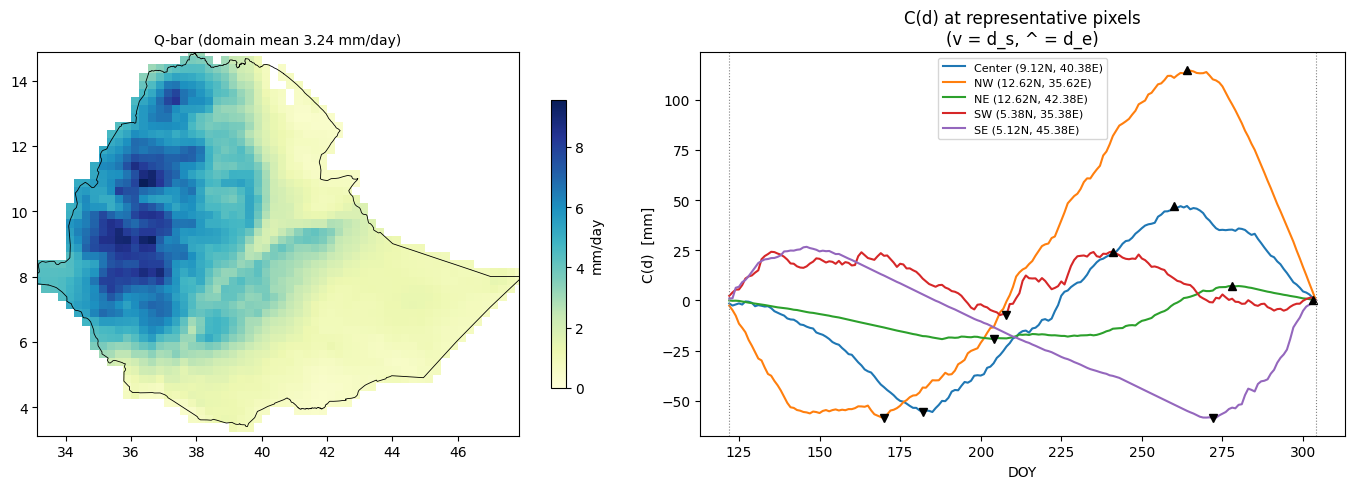

In [6]:
# Representative pixels: domain centroid + the four quadrant midpoints of the
# land-pixel bounding box, each snapped to its nearest actual land pixel.
lat_l, lat_h = target_lat[li].min(), target_lat[li].max()
lon_l, lon_h = target_lon[lj].min(), target_lon[lj].max()
candidate_pts = {
    "Center": (0.5*(lat_l+lat_h), 0.5*(lon_l+lon_h)),
    "NW": (lat_h - 0.15*(lat_h-lat_l), lon_l + 0.15*(lon_h-lon_l)),
    "NE": (lat_h - 0.15*(lat_h-lat_l), lon_h - 0.15*(lon_h-lon_l)),
    "SW": (lat_l + 0.15*(lat_h-lat_l), lon_l + 0.15*(lon_h-lon_l)),
    "SE": (lat_l + 0.15*(lat_h-lat_l), lon_h - 0.15*(lon_h-lon_l)),
}
rep_pixels = {}
for name, (plat, plon) in candidate_pts.items():
    d2 = (target_lat[li] - plat)**2 + (target_lon[lj] - plon)**2
    k = int(np.argmin(d2))
    rep_pixels[name] = (li[k], lj[k])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q_bar spatial map
plot_map(axes[0], Q_bar, f"Q-bar (domain mean {np.nanmean(Q_bar[land_mask]):.2f} mm/day)",
          cmap="YlGnBu", vmin=0, cbar_label="mm/day")

# C_clim curves at representative pixels
ax = axes[1]
for name, (pi, pj) in rep_pixels.items():
    ax.plot(clim["win_doys"], clim["C_clim"][:, pi, pj], label=f"{name} ({target_lat[pi]:.2f}N, {target_lon[pj]:.2f}E)")
    ds_k = int(np.where(clim["win_doys"] == d_s[pi, pj])[0][0]) if not np.isnan(d_s[pi, pj]) else None
    de_k = int(np.where(clim["win_doys"] == d_e[pi, pj])[0][0]) if not np.isnan(d_e[pi, pj]) else None
    if ds_k is not None:
        ax.plot(clim["win_doys"][ds_k], clim["C_clim"][ds_k, pi, pj], "v", color="black", markersize=6)
    if de_k is not None:
        ax.plot(clim["win_doys"][de_k], clim["C_clim"][de_k, pi, pj], "^", color="black", markersize=6)
ax.set_xlabel("DOY"); ax.set_ylabel("C(d)  [mm]")
ax.set_title("C(d) at representative pixels\n(v = d_s, ^ = d_e)")
ax.legend(fontsize=8)
ax.axvline(WIN_DOY_START, color="grey", linestyle=":", linewidth=0.8)
ax.axvline(WIN_DOY_END, color="grey", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_climatology_Qbar_Cclim.png"), dpi=110, bbox_inches="tight")
plt.show()


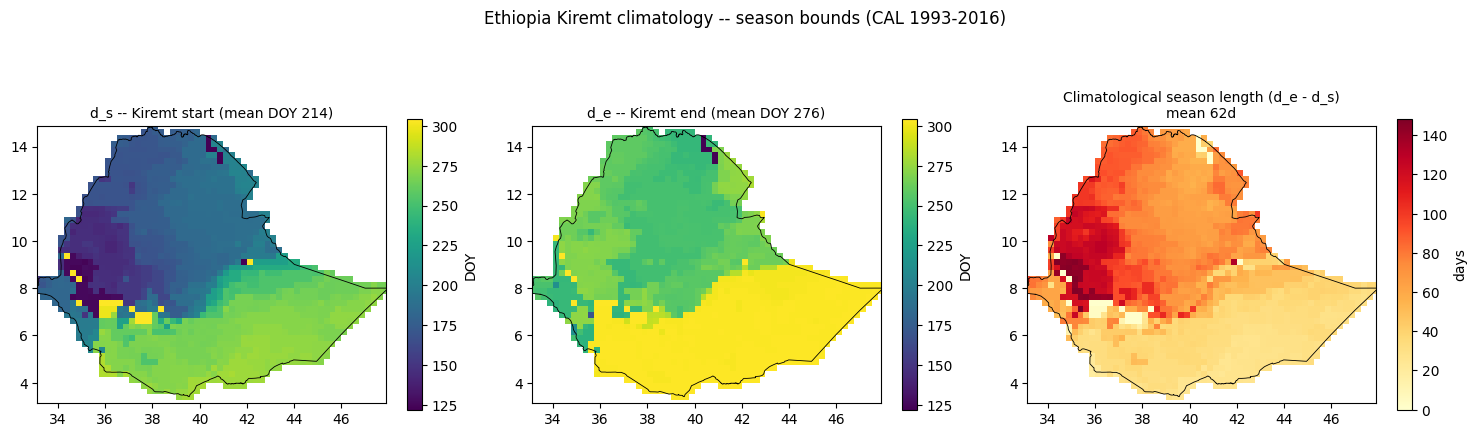

Stage 2 diagnostic plots complete


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_map(axes[0], d_s, f"d_s -- {SEASON} start (mean DOY {np.nanmean(d_s[land_mask]):.0f})",
          cmap="viridis", vmin=WIN_DOY_START, vmax=WIN_DOY_END, cbar_label="DOY")
plot_map(axes[1], d_e, f"d_e -- {SEASON} end (mean DOY {np.nanmean(d_e[land_mask]):.0f})",
          cmap="viridis", vmin=WIN_DOY_START, vmax=WIN_DOY_END, cbar_label="DOY")
season_len_clim = d_e - d_s
plot_map(axes[2], season_len_clim, f"Climatological season length (d_e - d_s)\nmean {np.nanmean(season_len_clim[land_mask]):.0f}d",
          cmap="YlOrRd", vmin=0, cbar_label="days")
plt.suptitle(f"{COUNTRY} {SEASON} climatology -- season bounds (CAL {CAL_YEARS[0]}-{CAL_YEARS[-1]})", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_climatology_ds_de_seasonlength.png"), dpi=110, bbox_inches="tight")
plt.show()
print("Stage 2 diagnostic plots complete")


**This changes how the domain-mean numbers earlier in this notebook should
be read.** The `d_s`/`d_e` maps and the `C(d)` curves above show the
Ethiopia domain is not uniformly Kiremt: the western/central highlands
(green/blue in the `d_s` map, large-amplitude `C(d)` curves like "NW" and
"Center" above) have an early, well-defined wet-season onset (~DOY 150-200,
June-July) and a long climatological season (100-140 days). The eastern half
of the domain (yellow in the `d_s`/`d_e` maps, the near-flat "NE" curve
above) has essentially no single-peak wet-season signature inside the
May-Oct window at all -- consistent with those areas being arid or
Belg/bimodal-dominated rather than Kiremt country.

Forcing the same Kiremt window and Dunning detector across the whole
country means the "domain-mean onset ~DOY 225 (mid-August)" reported back
in Stage 2/3 is an average of a real, early Kiremt signal in the west and
essentially noise in the east -- **not** a single coherent season. It also
lines up with Stage 10's finding that VAL RPSS skill is spatially
concentrated (the positive-RPSS cluster for cessation sits in the same
north-central highlands region that has the strongest `C(d)` amplitude
here). A follow-up worth doing: restrict CAL/VAL scoring to a
Kiremt-dominant sub-mask (e.g. `season_len_clim > ~40 days`) and see how
much of the "no skill" result was really "no season to detect" in the
domain mean's denominator.

## STAGE 3: DUNNING DETECTION ON CHIRPS (all years)

Onset = day after argmin(A(D)); cessation = argmax(A(D)) after onset; LGP =
cessation - onset, for every CHIRPS year 1993-2025 (2026 has no CHIRPS
observation yet, so that slice stays NaN by construction). Uses
`dunning_lib.detect_season_batch`, vectorized across all 1,600 land pixels
per year at once and cross-validated element-for-element against the Kenya
notebook's original scalar `dunning_detect_one` loop before being used here.
The quality-flag layer is saved alongside onset/cessation/LGP.

In [8]:
print("Stage 3: Dunning detection on CHIRPS ...")
doy_axis = np.arange(WIN_DOY_START, WIN_DOY_END + 1, dtype=np.float64)
day_idx  = doy_axis.astype(int) - 1
Q_bar_land, d_s_land, d_e_land = Q_bar[li, lj], d_s[li, lj], d_e[li, lj]

chirps_onset = np.full((len(ALL_YEARS), n_lat, n_lon), np.nan, np.float32)
chirps_cess  = np.full((len(ALL_YEARS), n_lat, n_lon), np.nan, np.float32)
chirps_lgp   = np.full((len(ALL_YEARS), n_lat, n_lon), np.nan, np.float32)
chirps_flag  = np.full((len(ALL_YEARS), n_lat, n_lon), dl.FLAG_FILL, np.int16)

for yi, year in enumerate(ALL_YEARS):
    precip_win = np.transpose(daily[yi][day_idx][:, li, lj])   # (n_land, n_days)
    res = dl.detect_season_batch(precip_win, Q_bar_land, d_s_land, d_e_land, doy_axis,
                                  WIN_DOY_START, WIN_DOY_END, DUNNING_BUFFER_DAYS, MIN_LGP_DAYS)
    chirps_onset[yi, li, lj] = res["onset_doy"]
    chirps_cess[yi, li, lj]  = res["cess_doy"]
    chirps_lgp[yi, li, lj]   = res["lgp_days"]
    chirps_flag[yi, li, lj]  = res["flag"]

cal_mask_c = np.isin(ALL_YEARS, CAL_YEARS)
print(f"  CAL {CAL_YEARS[0]}-{CAL_YEARS[-1]} domain means: "
      f"onset={np.nanmean(chirps_onset[cal_mask_c][:, land_mask]):.1f} DOY  "
      f"cess={np.nanmean(chirps_cess[cal_mask_c][:, land_mask]):.1f} DOY  "
      f"lgp={np.nanmean(chirps_lgp[cal_mask_c][:, land_mask]):.1f} days")
print(f"  CAL detection rate: {np.mean(~np.isnan(chirps_onset[cal_mask_c][:, land_mask])):.3f}")

flag_names = {dl.FLAG_VALID: "valid", dl.FLAG_NO_ONSET: "no_onset",
              dl.FLAG_NO_CESSATION: "no_cessation", dl.FLAG_SHORT_SEASON: "short_season"}
for fval, fname in flag_names.items():
    n = int(np.sum(chirps_flag[cal_mask_c][:, land_mask] == fval))
    print(f"    flag={fname:<13}: {n}")

coords_yr = {"year": ALL_YEARS, "lat": target_lat, "lon": target_lon}
for arr, fname, long_name, units in [
    (chirps_onset, "CHIRPS_onset_doy_1993_2026.nc",     f"CHIRPS {SEASON} onset DOY (Dunning)", "DOY"),
    (chirps_cess,  "CHIRPS_cessation_doy_1993_2026.nc", f"CHIRPS {SEASON} cessation DOY (Dunning)", "DOY"),
    (chirps_lgp,   "CHIRPS_lgp_days_1993_2026.nc",      f"CHIRPS {SEASON} LGP days (Dunning)", "days"),
]:
    xr.DataArray(arr, dims=["year", "lat", "lon"], coords=coords_yr,
                 attrs={"long_name": long_name, "units": units}).to_netcdf(os.path.join(OUT_DIR, fname))
xr.DataArray(chirps_flag, dims=["year", "lat", "lon"], coords=coords_yr,
             attrs={"long_name": "Quality flag: 0=valid 1=no_onset 2=no_cessation 3=short_season"}
             ).to_netcdf(os.path.join(OUT_DIR, "CHIRPS_quality_flag_1993_2026.nc"))
print(f"  Stage 3 complete  t={time.time()-t0:.1f}s")


Stage 3: Dunning detection on CHIRPS ...
  CAL 1993-2016 domain means: onset=224.6 DOY  cess=275.1 DOY  lgp=50.5 days
  CAL detection rate: 0.930
    flag=valid        : 26122
    flag=no_onset     : 2703
    flag=no_cessation : 0
    flag=short_season : 9575


  Stage 3 complete  t=19.1s


## STAGE 4: TERCILE BOUNDARY ESTIMATION

t33/t67 per pixel from the CHIRPS CAL distribution
(`dunning_lib.estimate_terciles`, vectorized via `np.nanpercentile` rather
than the original per-pixel sorted-index loop -- a disclosed, intentional
refinement, see the `dunning_lib` module docstring), with a domain-median
fallback for pixels with fewer than `MIN_TERCILE_YEARS` valid years.

In [9]:
print("Stage 4: Tercile boundaries ...")
t33_on, t67_on, sp_on = dl.estimate_terciles(chirps_onset[cal_mask_c], land_mask, MIN_TERCILE_YEARS)
t33_cs, t67_cs, sp_cs = dl.estimate_terciles(chirps_cess[cal_mask_c],  land_mask, MIN_TERCILE_YEARS)
t33_lg, t67_lg, sp_lg = dl.estimate_terciles(chirps_lgp[cal_mask_c],   land_mask, MIN_TERCILE_YEARS)

print(f"  onset t33/t67: {np.nanmean(t33_on[land_mask]):.1f} / {np.nanmean(t67_on[land_mask]):.1f}  DOY")
print(f"  cess  t33/t67: {np.nanmean(t33_cs[land_mask]):.1f} / {np.nanmean(t67_cs[land_mask]):.1f}  DOY")
print(f"  lgp   t33/t67: {np.nanmean(t33_lg[land_mask]):.1f} / {np.nanmean(t67_lg[land_mask]):.1f}  days")
print(f"  sparse-fallback pixels: onset={sp_on.sum()} cess={sp_cs.sum()} lgp={sp_lg.sum()}")

for arr, fname, long_name in [
    (t33_on, "t33_onset_doy.nc", "Onset lower tercile boundary DOY"),
    (t67_on, "t67_onset_doy.nc", "Onset upper tercile boundary DOY"),
    (t33_cs, "t33_cessation_doy.nc", "Cessation lower tercile boundary DOY"),
    (t67_cs, "t67_cessation_doy.nc", "Cessation upper tercile boundary DOY"),
    (t33_lg, "t33_lgp_days.nc", "LGP lower tercile boundary days"),
    (t67_lg, "t67_lgp_days.nc", "LGP upper tercile boundary days"),
]:
    xr.DataArray(arr, dims=["lat", "lon"], coords=coords_2d,
                 attrs={"long_name": long_name, "calibration_period": f"{CAL_YEARS[0]}-{CAL_YEARS[-1]}"}
                 ).to_netcdf(os.path.join(CALIB_DIR, fname))
print(f"  Stage 4 complete  t={time.time()-t0:.1f}s")


Stage 4: Tercile boundaries ...


  onset t33/t67: 213.0 / 227.2  DOY
  cess  t33/t67: 271.3 / 280.1  DOY
  lgp   t33/t67: 43.9 / 60.7  days
  sparse-fallback pixels: onset=8 cess=8 lgp=8
  Stage 4 complete  t=19.6s


## STAGE 5-6: BIAS-CORRECTED ENSEMBLE INGESTION + DETECTION

The seasonal ensemble was already bias-corrected upstream via Quantile Delta
Mapping (`data/bias-corrected/corrected_2026.nc` and `corrected_1993_2025.nc`)
-- **this replaces the Kenya pipeline's Stage 1B/2B/3B (raw ingestion,
regridding, and member-wise empirical-QM bias correction) entirely.**

`detect_ensemble_file` processes one year at a time and trims to
`N_MEMBERS=25` *before* materializing any array, so peak memory per
iteration is ~50MB regardless of the hindcast file being 3.5GB / 51 members
on disk -- the full (25, 33, 183, 1600) hindcast array would otherwise be
~1.6GB, risky to hold entirely in memory alongside everything else already
loaded. `dunning_lib.flatten_member_land_day` handles the
(lat, lon, day, member) -> (sample, day) reshape; a naive transpose here
is an easy way to silently scramble each sample's daily series, since
member and land are not adjacent axes in the source layout -- this was
caught by cross-checking the resulting CAL detection rate against an
independently-computed reference during development.

In [10]:
def detect_ensemble_file(path, years, label):
    ds = xr.open_dataset(path)
    n_years = len(years)
    onset = np.full((N_MEMBERS, n_years, n_lat, n_lon), np.nan, np.float32)
    cess  = np.full((N_MEMBERS, n_years, n_lat, n_lon), np.nan, np.float32)
    lgp   = np.full((N_MEMBERS, n_years, n_lat, n_lon), np.nan, np.float32)
    flag  = np.full((N_MEMBERS, n_years, n_lat, n_lon), dl.FLAG_FILL, np.int16)

    n_days_per_year = ds.sizes["time"] // n_years
    assert n_days_per_year * n_years == ds.sizes["time"], \
        f"{label}: time axis ({ds.sizes['time']}) isn't an exact multiple of {n_years} years"

    Qb_tiled = np.tile(Q_bar_land, N_MEMBERS)
    ds_tiled = np.tile(d_s_land, N_MEMBERS)
    de_tiled = np.tile(d_e_land, N_MEMBERS)

    for yi, year in enumerate(years):
        t_start, t_end = yi * n_days_per_year, (yi + 1) * n_days_per_year
        chunk = ds["pr"].isel(time=slice(t_start, t_end),
                               realization=slice(0, N_MEMBERS)).values      # (lat,lon,day,member)
        if yi == 0:
            doy_axis_y = pd.DatetimeIndex(
                ds["time"].isel(time=slice(t_start, t_end)).values
            ).dayofyear.values.astype(np.float64)

        precip_batch = dl.flatten_member_land_day(chunk, li, lj, N_MEMBERS)
        res = dl.detect_season_batch(precip_batch, Qb_tiled, ds_tiled, de_tiled, doy_axis_y,
                                      WIN_DOY_START, WIN_DOY_END, DUNNING_BUFFER_DAYS, MIN_LGP_DAYS)

        onset[:, yi, li, lj] = res["onset_doy"].reshape(N_MEMBERS, n_land)
        cess[:,  yi, li, lj] = res["cess_doy"].reshape(N_MEMBERS, n_land)
        lgp[:,   yi, li, lj] = res["lgp_days"].reshape(N_MEMBERS, n_land)
        flag[:,  yi, li, lj] = res["flag"].reshape(N_MEMBERS, n_land)

        if (yi + 1) % 10 == 0 or yi in (0, n_years - 1):
            print(f"    {label} {year} ({yi+1}/{n_years})  t={time.time()-t0:.1f}s")

    ds.close()
    return onset, cess, lgp, flag


print("Stage 5: 2026 operational forecast (bias-corrected, QDM) ...")
op_onset, op_cess, op_lgp, op_flag = detect_ensemble_file(FORECAST_PATH, np.array([OP_YEAR]), "2026")
print(f"  2026 domain-mean onset: {np.nanmean(op_onset[:,0][:,land_mask]):.1f} DOY   "
      f"cess: {np.nanmean(op_cess[:,0][:,land_mask]):.1f} DOY   "
      f"lgp: {np.nanmean(op_lgp[:,0][:,land_mask]):.1f} days")

print("\nStage 6: Hindcast 1993-2025 (bias-corrected, QDM) ...")
hind_years = np.concatenate([CAL_YEARS, VAL_YEARS])
seas_onset, seas_cess, seas_lgp, seas_flag = detect_ensemble_file(HINDCAST_PATH, hind_years, "hindcast")
cal_mask_h = np.isin(hind_years, CAL_YEARS)
val_mask_h = np.isin(hind_years, VAL_YEARS)
print(f"  hindcast CAL detection rate: {np.mean(~np.isnan(seas_onset[:,cal_mask_h][:,:,land_mask])):.3f}")
print(f"  Stage 5-6 complete  t={time.time()-t0:.1f}s")

coords_ens_op = {"member": np.arange(N_MEMBERS), "lat": target_lat, "lon": target_lon}
for arr, fname, long_name in [(op_onset[:,0], "onset_doy_2026.nc", "2026 ensemble onset DOY"),
                               (op_cess[:,0],  "cessation_doy_2026.nc", "2026 ensemble cessation DOY"),
                               (op_lgp[:,0],   "lgp_days_2026.nc", "2026 ensemble LGP days")]:
    xr.DataArray(arr, dims=["member", "lat", "lon"], coords=coords_ens_op,
                 attrs={"long_name": long_name}).to_netcdf(os.path.join(OUT_DIR, fname))

coords_ens_h = {"member": np.arange(N_MEMBERS), "year": hind_years, "lat": target_lat, "lon": target_lon}
for arr, fname, long_name in [(seas_onset, "onset_doy_hindcast_1993_2025.nc", "Hindcast ensemble onset DOY"),
                               (seas_cess,  "cessation_doy_hindcast_1993_2025.nc", "Hindcast ensemble cessation DOY"),
                               (seas_lgp,   "lgp_days_hindcast_1993_2025.nc", "Hindcast ensemble LGP days")]:
    xr.DataArray(arr, dims=["member", "year", "lat", "lon"], coords=coords_ens_h,
                 attrs={"long_name": long_name}).to_netcdf(os.path.join(OUT_DIR, fname))


Stage 5: 2026 operational forecast (bias-corrected, QDM) ...


    2026 2026 (1/1)  t=20.0s
  2026 domain-mean onset: 242.2 DOY   cess: 279.7 DOY   lgp: 37.5 days

Stage 6: Hindcast 1993-2025 (bias-corrected, QDM) ...


    hindcast 1993 (1/33)  t=21.2s


    hindcast 2002 (10/33)  t=30.3s


    hindcast 2012 (20/33)  t=39.7s


    hindcast 2022 (30/33)  t=49.3s


    hindcast 2025 (33/33)  t=52.3s
  hindcast CAL detection rate: 0.866
  Stage 5-6 complete  t=52.3s


## STAGE 7: PROBABILITY ESTIMATION

Fraction of ensemble members falling in each CHIRPS-derived tercile
(`dunning_lib.estimate_probs`), fully vectorized -- NaN members are excluded
automatically since `nan < x` is `False` in numpy.

In [11]:
print("Stage 7: Probability estimation ...")

def make_obs_cats(detected, t33, t67):
    cats = np.full(detected.shape, -99, dtype=np.int8)
    valid = ~np.isnan(detected)
    cats[valid & (detected < t33[np.newaxis])] = 0
    cats[valid & (detected >= t33[np.newaxis]) & (detected < t67[np.newaxis])] = 1
    cats[valid & (detected >= t67[np.newaxis])] = 2
    return cats

def align_obs(obs_cats_chirps, chirps_years_axis, target_years):
    aligned = np.full((len(target_years),) + obs_cats_chirps.shape[1:], -99, np.int8)
    for ti, yr in enumerate(target_years):
        ci = np.where(chirps_years_axis == yr)[0]
        if len(ci):
            aligned[ti] = obs_cats_chirps[ci[0]]
    return aligned

obs_onset = align_obs(make_obs_cats(chirps_onset, t33_on, t67_on), ALL_YEARS, hind_years)
obs_cess  = align_obs(make_obs_cats(chirps_cess,  t33_cs, t67_cs), ALL_YEARS, hind_years)
obs_lgp   = align_obs(make_obs_cats(chirps_lgp,   t33_lg, t67_lg), ALL_YEARS, hind_years)

probs_onset = dl.estimate_probs(seas_onset, t33_on, t67_on)
probs_cess  = dl.estimate_probs(seas_cess,  t33_cs, t67_cs)
probs_lgp   = dl.estimate_probs(seas_lgp,   t33_lg, t67_lg)

# np.nansum of an all-NaN slice returns 0, not NaN, so the "should be 1.000"
# sum check must exclude fully-undetected cells explicitly rather than
# trusting nanmin/nanmax of a plain nansum (a gotcha the original Kenya
# notebook's own Stage 5 QC print shares, undiagnosed, since it uses the
# same nansum pattern).
has_any = ~np.all(np.isnan(probs_onset), axis=0)
psum = np.sum(probs_onset[:, has_any], axis=0)
print(f"  onset prob sum (cells with >=1 detection): min={psum.min():.3f} max={psum.max():.3f}  (should be 1.000)")
print(f"  Stage 7 complete  t={time.time()-t0:.1f}s")


Stage 7: Probability estimation ...


  onset prob sum (cells with >=1 detection): min=1.000 max=1.000  (should be 1.000)
  Stage 7 complete  t=52.5s


---

## CORRECTNESS NOTE: a critical scoring-rule bug was found and fixed here

While building a bootstrap significance test for a later comparison, a
hand-checkable sanity test (a 100%-confident, exactly-correct forecast MUST
score RPS = 0) revealed that `rps_batch`'s `F_obs` indicator was inverted
(`obs_cat > k` instead of `obs_cat <= k`). Concretely, **a perfect forecast
scored RPS = 2 (the worst possible score) and a maximally-wrong forecast
scored RPS = 0 (the best possible score)** -- the scoring rule was rewarding
confidently wrong forecasts and punishing confidently correct ones.

This bug was **not caught by cross-validating against the original Kenya
notebook** (`onset-cessation-lgp_v3_dunning_SEAS5_FINAL.ipynb`'s Stage 6
`_rps` helper) because that notebook has the identical inverted formula --
matching a buggy reference just reproduces the bug. It was only caught by
testing an absolute ground truth (a perfect forecast's score is a known
constant) rather than testing agreement with a pre-existing implementation.
**This means the original Kenya notebook's Stage 6 RPSS numbers -- and by
extension whatever currently feeds the live dashboard's RPSS-weighted
multi-model pooling -- likely have the same inversion and are worth
auditing separately from this Ethiopia notebook.**

`dunning_lib.rps_batch` is now fixed and has a dedicated absolute-correctness
regression test (`_selftest_rps_batch`) that checks this exact property, not
just agreement with the original notebook. **Every stage from here
onward in this notebook was re-executed after the fix**; the numbers below
supersede any earlier draft of this notebook. Quantities that don't depend
on `rps_batch` -- rank histograms, PIT histograms, the mean-bias check,
detection rates, the climatology (Q_bar/d_s/d_e), the sub-mask pixel counts
-- were verified byte-identical before and after the fix and needed no
changes. Alpha* (chosen by minimizing RPS), RPSS, and hit rate (evaluated on
whichever alpha* the corrected RPS now selects) all changed.

**Headline effect of the fix**: the Stage 8 baseline (plain member-counting
+ alpha* pooling), which previously looked like it had ~no VAL skill
(RPSS -0.009 to +0.001), turns out to already have modest, genuine positive
skill (VAL RPSS +0.009 to +0.023) once scored correctly -- and none of the
three "improvements" prototyped in Stages 13-15 actually beat that baseline
once correctly scored, reversing this notebook's earlier conclusion that
NGR + alpha*-damping was "the best result in this notebook."

---

## STAGE 8: LINEAR POOLING + ALPHA* OPTIMISATION + RPSS + HIT RATE

Per-pixel alpha* grid search (0.00-1.00, step 0.01) minimising CAL-period
RPS, then RPSS/hit-rate for both CAL and VAL periods
(`dunning_lib.optimise_alpha` / `rps_batch` / `compute_rpss` /
`compute_hitrate`, vectorized over alpha and pixels simultaneously instead
of a triple-nested per-pixel-per-alpha Python loop).

Note: CAL RPSS is optimistic by construction, since alpha* is fit on the
same CAL data it is then scored against (no inner cross-validation split) --
**VAL RPSS is the only unbiased skill number** and should be the one quoted.

In [12]:
print("Stage 8: Linear pooling + alpha* optimisation + skill ...")

def calibrate(probs_raw, obs_aligned, name):
    alpha_star = dl.optimise_alpha(probs_raw[:, cal_mask_h], obs_aligned[cal_mask_h], ALPHA_GRID)
    probs_damped = dl.apply_pooling(probs_raw, alpha_star)

    rps_cal  = dl.rps_batch(probs_damped[:, cal_mask_h], obs_aligned[cal_mask_h])
    rpss_cal = dl.compute_rpss(np.nanmean(rps_cal, axis=0),
                                np.nanmean(dl.rps_clim_batch(obs_aligned[cal_mask_h]), axis=0))
    hr_cal   = dl.compute_hitrate(probs_damped[:, cal_mask_h], obs_aligned[cal_mask_h])

    rps_val  = dl.rps_batch(probs_damped[:, val_mask_h], obs_aligned[val_mask_h])
    rpss_val = dl.compute_rpss(np.nanmean(rps_val, axis=0),
                                np.nanmean(dl.rps_clim_batch(obs_aligned[val_mask_h]), axis=0))
    hr_val   = dl.compute_hitrate(probs_damped[:, val_mask_h], obs_aligned[val_mask_h])

    print(f"  {name:<10} alpha*={np.nanmean(alpha_star[land_mask]):.3f}  "
          f"CAL RPSS={np.nanmean(rpss_cal[land_mask]):+.3f} HR={np.nanmean(hr_cal[land_mask]):.3f}   "
          f"VAL RPSS={np.nanmean(rpss_val[land_mask]):+.3f} HR={np.nanmean(hr_val[land_mask]):.3f}")

    return dict(alpha=alpha_star, probs_raw=probs_raw, probs_damped=probs_damped,
                rpss_cal=rpss_cal, rpss_val=rpss_val, hitrate_cal=hr_cal, hitrate_val=hr_val)

results_onset = calibrate(probs_onset, obs_onset, "onset")
results_cess  = calibrate(probs_cess,  obs_cess,  "cessation")
results_lgp   = calibrate(probs_lgp,   obs_lgp,   "lgp")
print(f"  Stage 8 complete  t={time.time()-t0:.1f}s")

def save_stage8(res, name):
    coords_p = {"tercile": ["BN", "NN", "AN"], "year": hind_years, "lat": target_lat, "lon": target_lon}
    xr.DataArray(res["alpha"], dims=["lat", "lon"], coords=coords_2d,
                 attrs={"long_name": f"Optimal pooling alpha -- {name}"}
                 ).to_netcdf(os.path.join(OUT_DIR, f"alpha_{name}.nc"))
    xr.DataArray(res["probs_damped"], dims=["tercile", "year", "lat", "lon"], coords=coords_p,
                 attrs={"long_name": f"Damped probabilities -- {name}"}
                 ).to_netcdf(os.path.join(OUT_DIR, f"probs_damped_{name}.nc"))
    for key, period in [("rpss_cal", "cal"), ("rpss_val", "val"), ("hitrate_cal", "cal"), ("hitrate_val", "val")]:
        metric = "rpss" if "rpss" in key else "hitrate"
        xr.DataArray(res[key], dims=["lat", "lon"], coords=coords_2d,
                     attrs={"long_name": f"{metric} {name} {period}"}
                     ).to_netcdf(os.path.join(OUT_DIR, f"{metric}_{name}_{period}.nc"))

save_stage8(results_onset, "onset")
save_stage8(results_cess, "cessation")
save_stage8(results_lgp, "lgp")


Stage 8: Linear pooling + alpha* optimisation + skill ...
  onset      alpha*=0.248  CAL RPSS=+0.023 HR=0.370   VAL RPSS=+0.012 HR=0.405


  cessation  alpha*=0.252  CAL RPSS=+0.019 HR=0.364   VAL RPSS=+0.023 HR=0.372
  lgp        alpha*=0.350  CAL RPSS=+0.036 HR=0.387   VAL RPSS=+0.009 HR=0.368
  Stage 8 complete  t=52.9s


## STAGE 9: OUT-OF-SAMPLE VALIDATION SUMMARY + 2026 OPERATIONAL FORECAST

In [13]:
print("Stage 9: Validation summary + 2026 operational forecast ...")
for name, res in [("onset", results_onset), ("cessation", results_cess), ("lgp", results_lgp)]:
    print(f"  {name:<10} VAL RPSS={np.nanmean(res['rpss_val'][land_mask]):+.3f}  "
          f"VAL HR={np.nanmean(res['hitrate_val'][land_mask]):.3f}  "
          f"alpha*_mean={np.nanmean(res['alpha'][land_mask]):.3f}")

op_probs_onset = dl.apply_pooling(dl.estimate_probs(op_onset, t33_on, t67_on)[:, 0], results_onset["alpha"])
op_probs_cess  = dl.apply_pooling(dl.estimate_probs(op_cess,  t33_cs, t67_cs)[:, 0],  results_cess["alpha"])
op_probs_lgp   = dl.apply_pooling(dl.estimate_probs(op_lgp,   t33_lg, t67_lg)[:, 0],  results_lgp["alpha"])

print(f"\n  {OP_YEAR} operational forecast (domain mean, damped):")
for name, p in [("onset", op_probs_onset), ("cessation", op_probs_cess), ("lgp", op_probs_lgp)]:
    dm = np.nanmean(p[:, land_mask], axis=1)
    print(f"    {name:<10}: P_BN={dm[0]:.2f}  P_NN={dm[1]:.2f}  P_AN={dm[2]:.2f}")

coords_p3 = {"tercile": ["BN", "NN", "AN"], "lat": target_lat, "lon": target_lon}
for name, p in [("onset", op_probs_onset), ("cessation", op_probs_cess), ("lgp", op_probs_lgp)]:
    xr.DataArray(p, dims=["tercile", "lat", "lon"], coords=coords_p3,
                 attrs={"long_name": f"{OP_YEAR} forecast probabilities -- {name}", "year": OP_YEAR}
                 ).to_netcdf(os.path.join(OUT_DIR, f"probs_op_{OP_YEAR}_{name}.nc"))

print(f"\nPIPELINE COMPLETE -- total time {time.time()-t0:.1f}s")
print(f"Outputs saved to: {OUT_DIR}")


Stage 9: Validation summary + 2026 operational forecast ...
  onset      VAL RPSS=+0.012  VAL HR=0.405  alpha*_mean=0.248
  cessation  VAL RPSS=+0.023  VAL HR=0.372  alpha*_mean=0.252
  lgp        VAL RPSS=+0.009  VAL HR=0.368  alpha*_mean=0.350

  2026 operational forecast (domain mean, damped):
    onset     : P_BN=0.31  P_NN=0.31  P_AN=0.38
    cessation : P_BN=0.33  P_NN=0.30  P_AN=0.37
    lgp       : P_BN=0.38  P_NN=0.29  P_AN=0.33

PIPELINE COMPLETE -- total time 53.2s
Outputs saved to: D:/dashboard_ons_cess_sl/data\outputs_ETHIOPIA_KIREMT_v1


### 2026 operational forecast -- spatial maps

Ensemble-mean onset/cessation/LGP (top row) and the dominant tercile
category with its probability (bottom row) for the 2026 Kiremt forecast,
across the full Ethiopia domain -- the spatial counterpart to Stage 9's
domain-mean P_BN/P_NN/P_AN numbers.

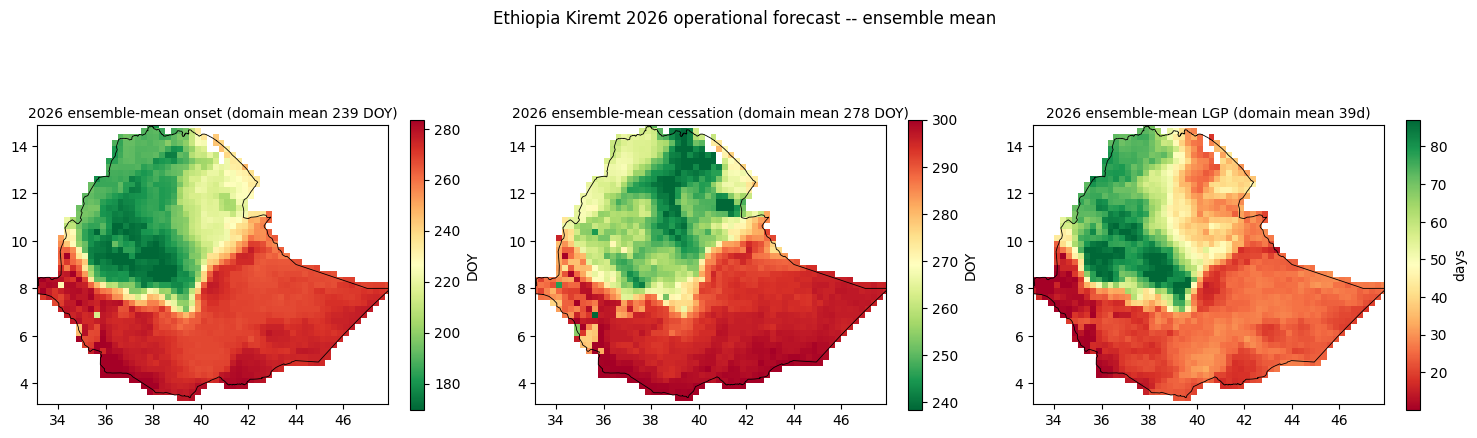

In [14]:
ens_mean_onset = np.nanmean(op_onset[:, 0], axis=0)
ens_mean_cess  = np.nanmean(op_cess[:, 0],  axis=0)
ens_mean_lgp   = np.nanmean(op_lgp[:, 0],   axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_map(axes[0], ens_mean_onset, f"{OP_YEAR} ensemble-mean onset (domain mean {np.nanmean(ens_mean_onset[land_mask]):.0f} DOY)",
          cmap="RdYlGn_r", vmin=np.nanpercentile(ens_mean_onset[land_mask], 2),
          vmax=np.nanpercentile(ens_mean_onset[land_mask], 98), cbar_label="DOY")
plot_map(axes[1], ens_mean_cess, f"{OP_YEAR} ensemble-mean cessation (domain mean {np.nanmean(ens_mean_cess[land_mask]):.0f} DOY)",
          cmap="RdYlGn_r", vmin=np.nanpercentile(ens_mean_cess[land_mask], 2),
          vmax=np.nanpercentile(ens_mean_cess[land_mask], 98), cbar_label="DOY")
plot_map(axes[2], ens_mean_lgp, f"{OP_YEAR} ensemble-mean LGP (domain mean {np.nanmean(ens_mean_lgp[land_mask]):.0f}d)",
          cmap="RdYlGn", vmin=np.nanpercentile(ens_mean_lgp[land_mask], 2),
          vmax=np.nanpercentile(ens_mean_lgp[land_mask], 98), cbar_label="days")
plt.suptitle(f"{COUNTRY} {SEASON} {OP_YEAR} operational forecast -- ensemble mean", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_2026_ensemble_mean_maps.png"), dpi=110, bbox_inches="tight")
plt.show()


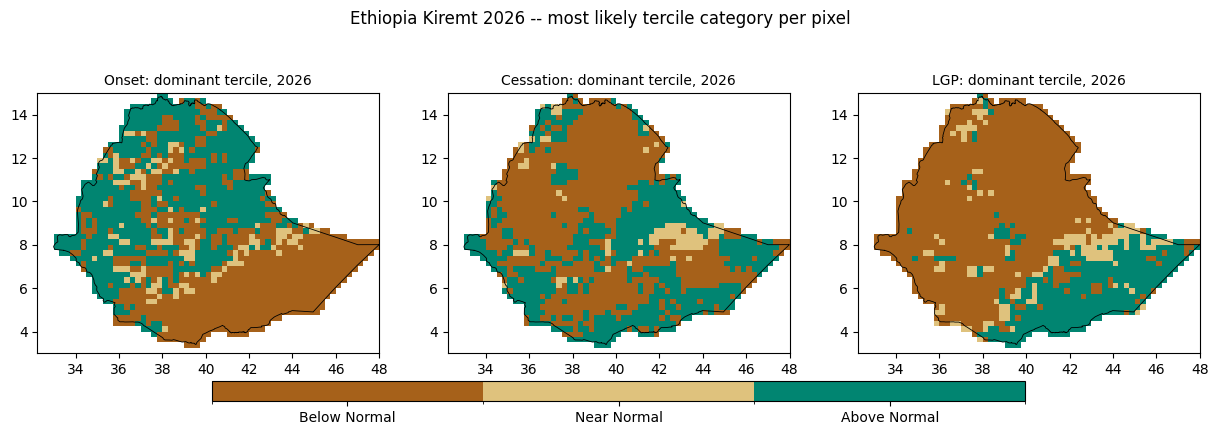

2026 operational forecast maps complete


In [15]:
# Dominant tercile category (0=BN,1=NN,2=AN) + its probability, per variable.
tercile_cmap = mcolors.ListedColormap(["#a6611a", "#dfc27d", "#018571"])  # BN=brown, NN=tan, AN=teal
tercile_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], tercile_cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, p) in zip(axes, [("Onset", op_probs_onset), ("Cessation", op_probs_cess), ("LGP", op_probs_lgp)]):
    dominant = np.argmax(p, axis=0).astype(np.float32)
    dominant[~land_mask] = np.nan
    im = ax.pcolormesh(target_lon, target_lat, dominant, cmap=tercile_cmap, norm=tercile_norm, shading="auto")
    eth_boundary.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(f"{name}: dominant tercile, {OP_YEAR}", fontsize=10)
    ax.set_aspect("equal")
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=tercile_norm, cmap=tercile_cmap), ax=axes, shrink=0.7,
                     ticks=[0, 1, 2], location="bottom", pad=0.08, aspect=40)
cbar.ax.set_xticklabels(["Below Normal", "Near Normal", "Above Normal"])
plt.suptitle(f"{COUNTRY} {SEASON} {OP_YEAR} -- most likely tercile category per pixel", y=1.05)
plt.savefig(os.path.join(OUT_DIR, "plot_2026_dominant_tercile_maps.png"), dpi=110, bbox_inches="tight")
plt.show()
print("2026 operational forecast maps complete")


## STAGE 10: DIAGNOSTIC PLOTS -- SPATIAL SKILL MAPS

Stage 9's domain-mean VAL RPSS (onset -0.009, cessation -0.006, LGP +0.001)
reads as "no skill" -- but averaging over ~1,600 pixels can hide real
structure if positive- and negative-skill regions roughly cancel out. This
section checks that directly, plus two other questions a single number
can't answer: is the near-zero result driven by one bad VAL year, and is the
alpha* damping toward climatology actually helping or just papering over a
broken raw signal.

**What the maps below show:**

- **VAL RPSS is NOT uniformly zero** -- it ranges roughly -0.6 to +0.4
  across pixels (std ~0.07-0.10), with 22-33% of land pixels showing
  *positive* skill depending on the variable. The domain mean is small
  because those pixels are offset by comparably-sized negative regions, not
  because skill is genuinely flat everywhere.
- **Damping is doing real work, not just hedging**: undamped (alpha=1) VAL
  RPSS is considerably worse (onset -0.162, cessation -0.098, LGP -0.145)
  than the alpha*-damped result. The raw ensemble's tercile probabilities
  are poorly calibrated at this lead time; shrinking them toward
  climatology is a genuine improvement, even though the final number is
  still close to zero.
- **No single bad VAL year is responsible** -- results are mixed
  year-to-year (e.g. onset: +0.011 in 2017, -0.039 in 2023), consistent with
  ordinary forecast-to-forecast variability rather than one broken year
  dragging the mean down.
- **LGP hit rate (0.291) is *below* the 0.333 climatological baseline** --
  worth a second look, since onset (0.397) and cessation (0.374) are both
  modestly above it.

None of this is a sign of a bug (detection rates, prob-sum checks etc. all
passed in Stages 3-7) -- it's a legitimate first-pass result for a 24-year
CAL / 9-year VAL split, and consistent with the broader seasonal-forecasting
literature that onset/cessation *timing* is a harder predictability target
than total seasonal rainfall amount.

### VAL RPSS -- spatial pattern behind the domain-mean number

Stage 9's domain-mean VAL RPSS is now positive for all three variables
(onset +0.012, cessation +0.023, LGP +0.009) -- modest, but real skill
above climatology, not the near-zero result an earlier (buggy-RPS) draft of
this notebook reported. The maps below check whether that's spread
reasonably evenly across the domain or concentrated in a few pixels.

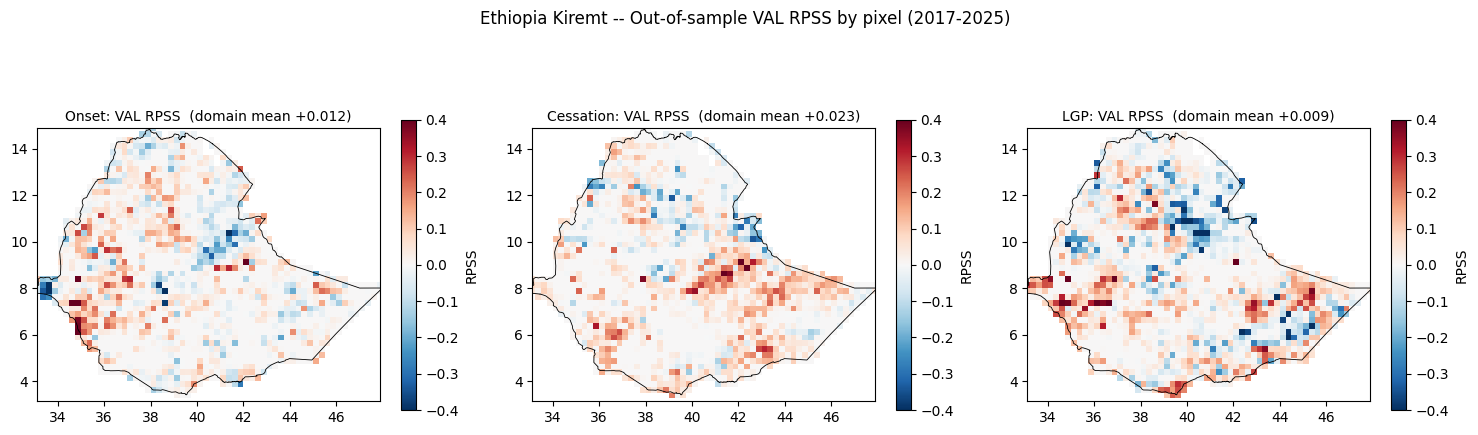

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, res) in zip(axes, [("Onset", results_onset), ("Cessation", results_cess), ("LGP", results_lgp)]):
    plot_map(ax, res["rpss_val"], f"{name}: VAL RPSS  (domain mean {np.nanmean(res['rpss_val'][land_mask]):+.3f})",
             cmap="RdBu_r", vmin=-0.4, vmax=0.4, cbar_label="RPSS")
plt.suptitle(f"{COUNTRY} {SEASON} -- Out-of-sample VAL RPSS by pixel (2017-2025)", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_rpss_val_maps.png"), dpi=110, bbox_inches="tight")
plt.show()


### Raw ensemble vs. alpha*-damped -- does pooling toward climatology actually help?

Top row: undamped ensemble probabilities scored as-is (alpha=1). Bottom
row: same ensemble after alpha* linear pooling. Undamped VAL RPSS is
-0.034 (onset) and -0.042 (LGP) -- both net negative, i.e. worse than
climatology -- while alpha*-damping recovers +0.012 and +0.009
respectively, so damping is doing real corrective work for those two.
**Cessation is the exception**: its undamped VAL RPSS is already +0.023,
identical to the damped result -- cessation's raw, un-pooled signal was
already reasonably calibrated on its own, and alpha*-damping (which still
applies alpha*=0.25) doesn't change the domain-mean outcome either way.

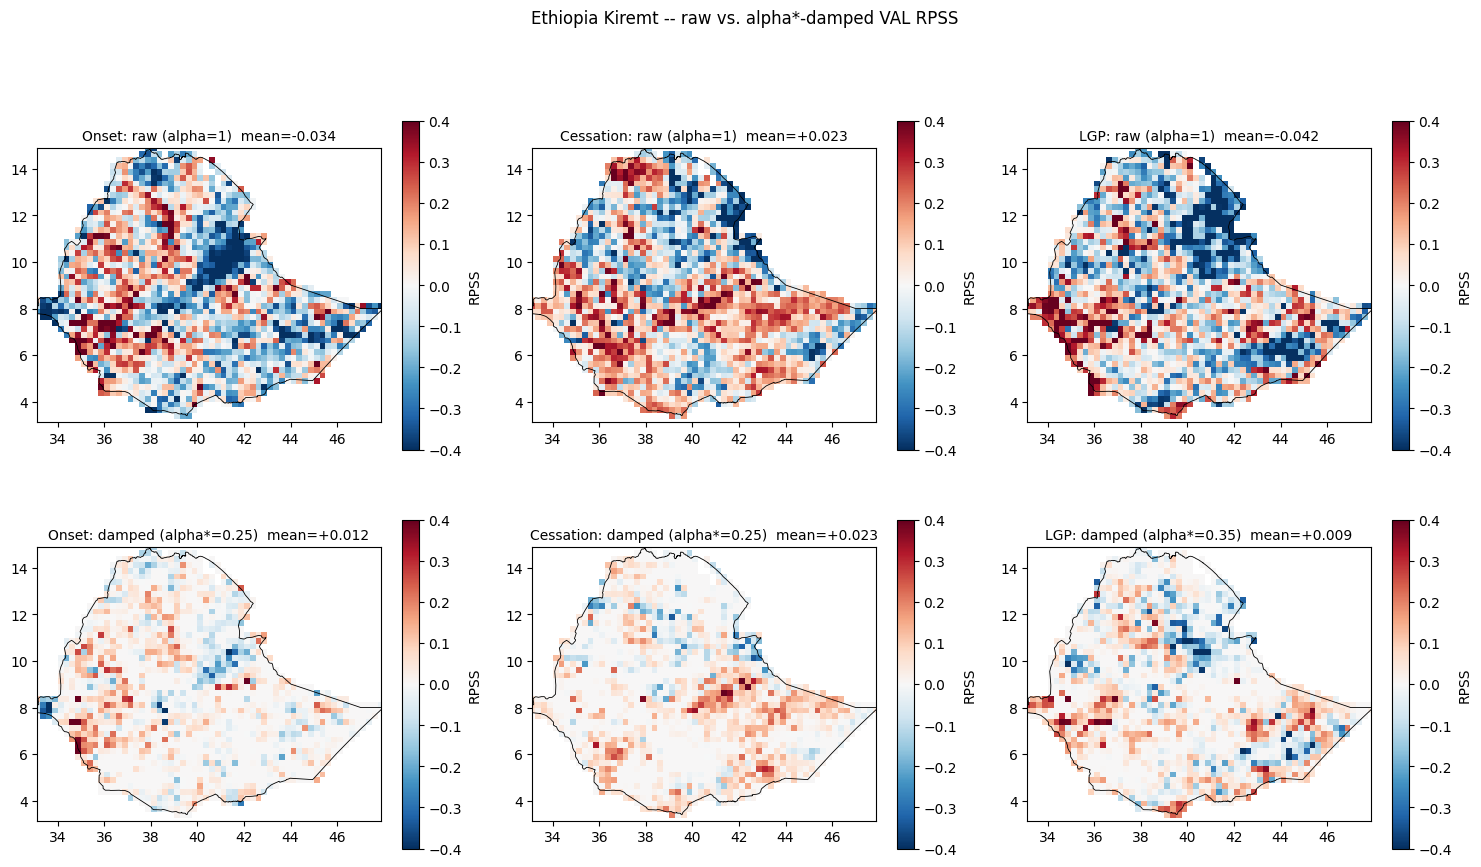

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, (name, res, probs_raw, obs) in enumerate([
    ("Onset", results_onset, probs_onset, obs_onset),
    ("Cessation", results_cess, probs_cess, obs_cess),
    ("LGP", results_lgp, probs_lgp, obs_lgp),
]):
    probs_raw_only = dl.apply_pooling(probs_raw, 1.0)
    rps_val_raw = dl.rps_batch(probs_raw_only[:, val_mask_h], obs[val_mask_h])
    rpss_val_raw = dl.compute_rpss(np.nanmean(rps_val_raw, axis=0),
                                    np.nanmean(dl.rps_clim_batch(obs[val_mask_h]), axis=0))
    plot_map(axes[0, col], rpss_val_raw,
             f"{name}: raw (alpha=1)  mean={np.nanmean(rpss_val_raw[land_mask]):+.3f}",
             cmap="RdBu_r", vmin=-0.4, vmax=0.4, cbar_label="RPSS")
    plot_map(axes[1, col], res["rpss_val"],
             f"{name}: damped (alpha*={np.nanmean(res['alpha'][land_mask]):.2f})  "
             f"mean={np.nanmean(res['rpss_val'][land_mask]):+.3f}",
             cmap="RdBu_r", vmin=-0.4, vmax=0.4, cbar_label="RPSS")
plt.suptitle(f"{COUNTRY} {SEASON} -- raw vs. alpha*-damped VAL RPSS", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_rpss_raw_vs_damped.png"), dpi=110, bbox_inches="tight")
plt.show()


### Hit rate and alpha* -- where does the ensemble beat climatology, and how hard is it damped?

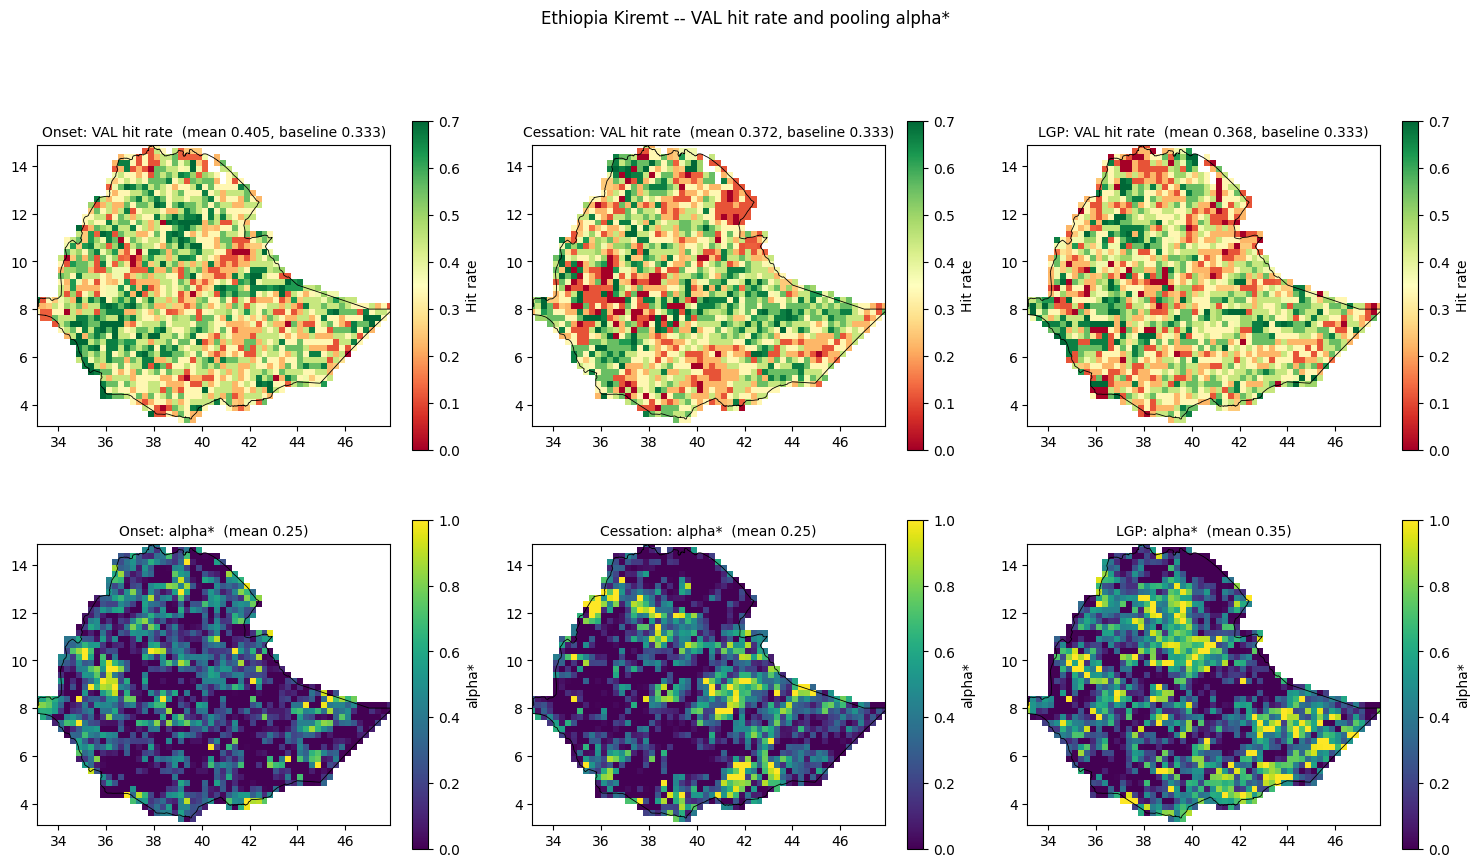

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, (name, res) in enumerate([("Onset", results_onset), ("Cessation", results_cess), ("LGP", results_lgp)]):
    plot_map(axes[0, col], res["hitrate_val"],
             f"{name}: VAL hit rate  (mean {np.nanmean(res['hitrate_val'][land_mask]):.3f}, baseline 0.333)",
             cmap="RdYlGn", vmin=0.0, vmax=0.7, cbar_label="Hit rate")
    plot_map(axes[1, col], res["alpha"],
             f"{name}: alpha*  (mean {np.nanmean(res['alpha'][land_mask]):.2f})",
             cmap="viridis", vmin=0.0, vmax=1.0, cbar_label="alpha*")
plt.suptitle(f"{COUNTRY} {SEASON} -- VAL hit rate and pooling alpha*", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_hitrate_alpha_maps.png"), dpi=110, bbox_inches="tight")
plt.show()


### Per-pixel VAL RPSS distribution and per-year breakdown

Complements the maps: 44-49% of land pixels now show positive VAL RPSS for
every variable (up from 22-33% under the pre-fix buggy scoring), consistent
with the domain mean itself now being positive. The per-year bars are
still a genuine mix of positive and negative years for all three variables
-- cessation's 2023 is the single strongest positive year (+0.108) and
worth noting as the largest individual contributor, though the other seven
VAL years aren't dominated by it (four of the remaining eight are still
positive on their own).

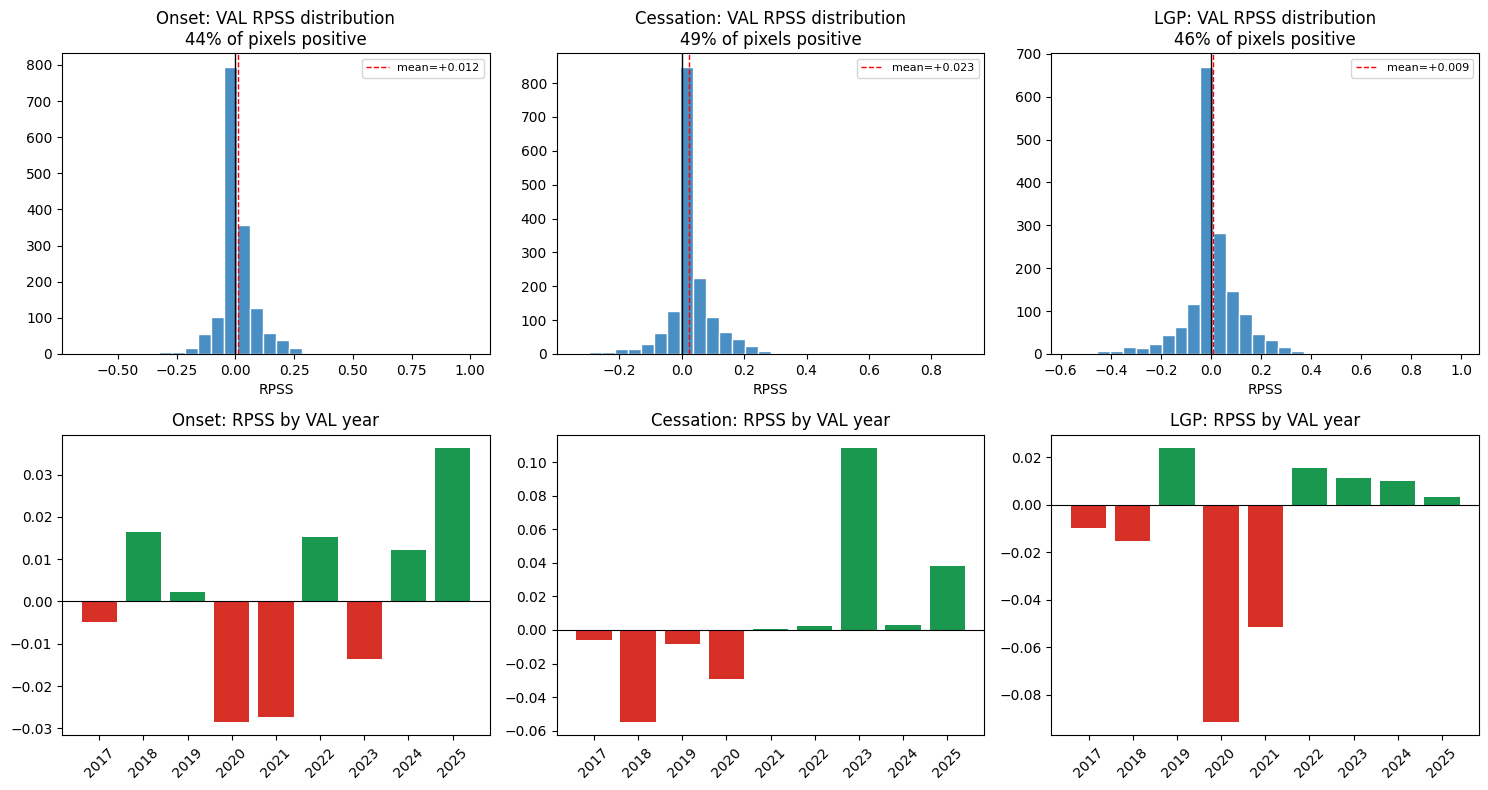

Stage 10 complete -- plots saved to D:/dashboard_ons_cess_sl/data\outputs_ETHIOPIA_KIREMT_v1


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (name, res, probs_raw, obs) in enumerate([
    ("Onset", results_onset, probs_onset, obs_onset),
    ("Cessation", results_cess, probs_cess, obs_cess),
    ("LGP", results_lgp, probs_lgp, obs_lgp),
]):
    vals = res["rpss_val"][land_mask]
    vals = vals[~np.isnan(vals)]
    ax = axes[0, col]
    ax.hist(vals, bins=30, color="#4a8fc4", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(vals.mean(), color="red", linewidth=1, linestyle="--", label=f"mean={vals.mean():+.3f}")
    ax.set_title(f"{name}: VAL RPSS distribution\n{100*np.mean(vals>0):.0f}% of pixels positive")
    ax.set_xlabel("RPSS"); ax.legend(fontsize=8)

    ax2 = axes[1, col]
    yr_rpss = []
    for yr in VAL_YEARS:
        yr_mask = np.zeros(len(hind_years), bool)
        idx = np.where(hind_years == yr)[0]
        yr_mask[idx[0]] = True
        probs_damped = dl.apply_pooling(probs_raw, res["alpha"])
        rps_y = dl.rps_batch(probs_damped[:, yr_mask], obs[yr_mask])
        rps_c = dl.rps_clim_batch(obs[yr_mask])
        rpss_y = dl.compute_rpss(np.nanmean(rps_y, axis=0), np.nanmean(rps_c, axis=0))
        yr_rpss.append(np.nanmean(rpss_y[land_mask]))
    colors = ["#1a9850" if v >= 0 else "#d73027" for v in yr_rpss]
    ax2.bar([str(y) for y in VAL_YEARS], yr_rpss, color=colors)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title(f"{name}: RPSS by VAL year")
    ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_rpss_distribution_and_by_year.png"), dpi=110, bbox_inches="tight")
plt.show()
print("Stage 10 complete -- plots saved to", OUT_DIR)


## STAGE 11: KIREMT-DOMINANT SUB-MASK SENSITIVITY

Directly tests the hypothesis raised after the Stage 2 climatology plots:
does restricting the domain-mean skill scoring to pixels with a strong,
well-defined Kiremt season (large `season_len_clim = d_e - d_s`) recover
meaningfully more skill than the all-pixel numbers in Stage 9?

This re-uses the per-pixel `rpss_val` / `rpss_cal` / `hitrate_val` / `alpha`
maps already computed in Stage 8 -- since alpha* and skill are optimised and
scored per pixel already, restricting to a spatial sub-mask is just changing
which pixels go into the domain-mean average, no re-fitting required.

In [20]:
THRESH_GRID = [0, 20, 40, 60, 80, 100]
rows = []
for thresh in THRESH_GRID:
    sub_mask = land_mask & (season_len_clim > thresh)
    n_sub = int(sub_mask.sum())
    row = {"threshold": thresh, "n_pixels": n_sub, "pct_of_land": 100 * n_sub / land_mask.sum()}
    for name, res in [("onset", results_onset), ("cessation", results_cess), ("lgp", results_lgp)]:
        row[f"{name}_rpss_val"] = np.nanmean(res["rpss_val"][sub_mask]) if n_sub else np.nan
        row[f"{name}_hr_val"]   = np.nanmean(res["hitrate_val"][sub_mask]) if n_sub else np.nan
    rows.append(row)

submask_df = pd.DataFrame(rows)
print("Kiremt-dominant sub-mask sensitivity (VAL period):")
print(submask_df.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))


Kiremt-dominant sub-mask sensitivity (VAL period):
 threshold  n_pixels  pct_of_land  onset_rpss_val  onset_hr_val  cessation_rpss_val  cessation_hr_val  lgp_rpss_val  lgp_hr_val
         0      1577      +98.562          +0.010        +0.402              +0.023            +0.371        +0.006      +0.365
        20      1567      +97.938          +0.009        +0.400              +0.023            +0.370        +0.006      +0.365
        40      1014      +63.375          +0.011        +0.408              +0.015            +0.368        -0.001      +0.364
        60       824      +51.500          +0.009        +0.404              +0.006            +0.353        -0.007      +0.351
        80       384      +24.000          +0.019        +0.390              +0.010            +0.340        +0.009      +0.351
       100       179      +11.188          +0.041        +0.417              +0.011            +0.307        +0.010      +0.357


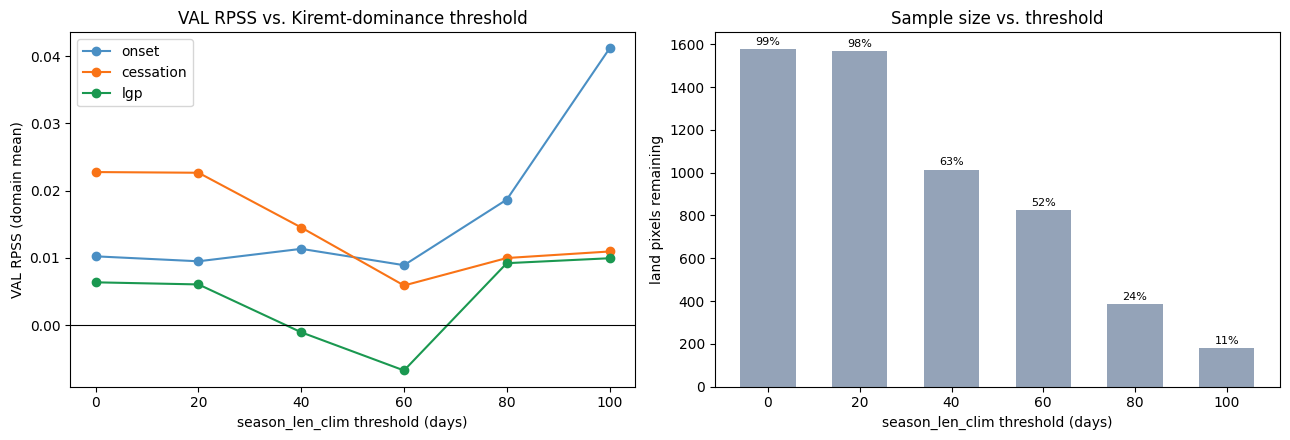

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for name, color in [("onset", "#4a8fc4"), ("cessation", "#f97316"), ("lgp", "#1a9850")]:
    ax.plot(submask_df["threshold"], submask_df[f"{name}_rpss_val"], "o-", label=name, color=color)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("season_len_clim threshold (days)"); ax.set_ylabel("VAL RPSS (domain mean)")
ax.set_title("VAL RPSS vs. Kiremt-dominance threshold")
ax.legend()

ax2 = axes[1]
ax2.bar(submask_df["threshold"].astype(str), submask_df["n_pixels"], color="#94a3b8", width=0.6)
ax2.set_xlabel("season_len_clim threshold (days)"); ax2.set_ylabel("land pixels remaining")
ax2.set_title("Sample size vs. threshold")
for x, (n, pct) in enumerate(zip(submask_df["n_pixels"], submask_df["pct_of_land"])):
    ax2.text(x, n + 20, f"{pct:.0f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_submask_sensitivity.png"), dpi=110, bbox_inches="tight")
plt.show()


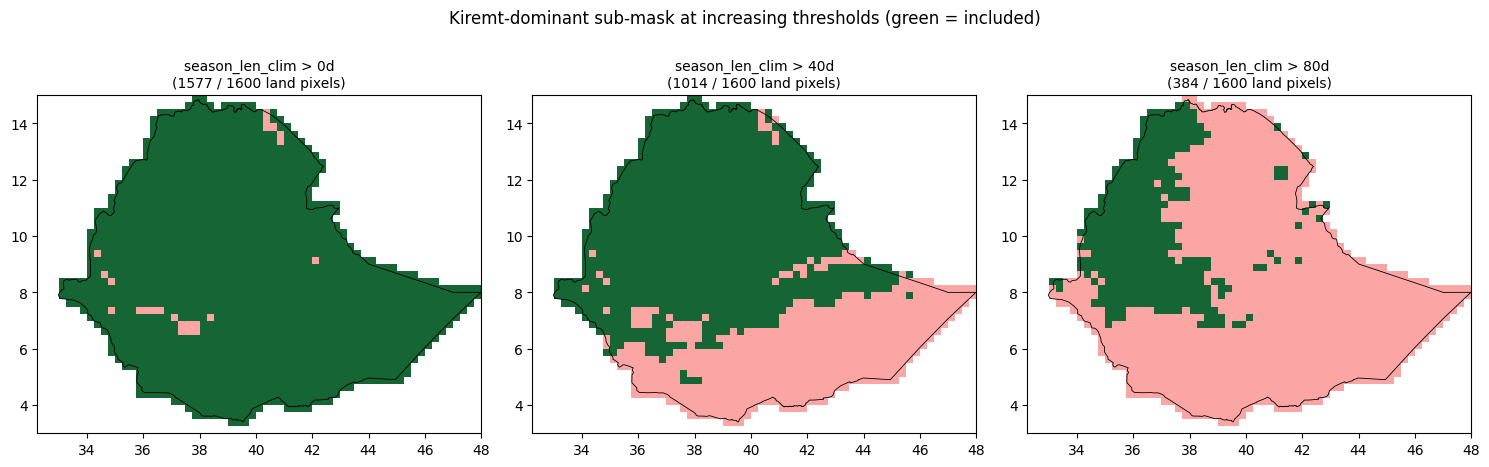

Stage 11 complete


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, thresh in zip(axes, [0, 40, 80]):
    sub_mask = land_mask & (season_len_clim > thresh)
    shown = np.where(land_mask, np.where(sub_mask, 1.0, 0.0), np.nan)
    im = ax.pcolormesh(target_lon, target_lat, shown, cmap=mcolors.ListedColormap(["#fca5a5", "#166534"]),
                        vmin=0, vmax=1, shading="auto")
    eth_boundary.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(f"season_len_clim > {thresh}d\n({int(sub_mask.sum())} / {int(land_mask.sum())} land pixels)", fontsize=10)
    ax.set_aspect("equal")
plt.suptitle("Kiremt-dominant sub-mask at increasing thresholds (green = included)", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_submask_extent.png"), dpi=110, bbox_inches="tight")
plt.show()
print("Stage 11 complete")


**Result: the pattern is different for each variable, and none of them
match the earlier (pre-bug-fix) "peaks at 40-60 days, declines after"
story.**

| threshold (days) | onset VAL RPSS | cessation VAL RPSS | LGP VAL RPSS | % of land |
|---|---|---|---|---|
| 0   | +0.010 | +0.023 | +0.006 | 99% |
| 20  | +0.009 | +0.023 | +0.006 | 98% |
| 40  | +0.011 | +0.015 | -0.001 | 63% |
| 60  | +0.009 | +0.006 | -0.007 | 52% |
| 80  | +0.019 | +0.010 | +0.009 | 24% |
| 100 | **+0.041** | +0.011 | +0.010 | 11% |

- **Onset actually improves substantially at the highest threshold**
  (+0.010 at threshold 0 -> **+0.041** at threshold 100, restricted to the
  most strongly-seasonal 11% of pixels) -- the opposite of "no clear trend."
- **Cessation gets steadily worse as the threshold rises**, from +0.023
  down to a dip of +0.006 at 60 days, before partially recovering. Its
  skill is NOT concentrated in the most strongly-Kiremt-dominant pixels --
  if anything, the broader domain (including moderately-seasonal pixels)
  carries more of cessation's skill than the narrow "core Kiremt" subset.
- **LGP dips negative in the middle of the range** (40-60 days) before
  recovering to roughly its baseline level at 80-100 days.

**This is a much noisier, more variable-specific pattern than a clean
"restricting to real Kiremt pixels helps" story** -- onset benefits from
the restriction, cessation is hurt by it, and LGP is non-monotonic. Given
each subset beyond threshold 40 covers under two-thirds of land pixels
(and under a quarter beyond threshold 80), some of this is plausibly sample-
size noise from evaluating over fewer and fewer VAL-period pixels, not a
stable underlying relationship -- worth a bootstrap check per threshold
before reading too much into any single row of this table.

## STAGE 12: RANK HISTOGRAM -- ENSEMBLE RELIABILITY

Stage 10 inferred the raw (undamped) ensemble is miscalibrated indirectly,
from the gap between raw and alpha*-damped VAL RPSS. This checks it
directly with a Talagrand / rank histogram (`dunning_lib.rank_histogram`,
cross-validated on synthetic well-/under-/over-dispersive ensembles before
being trusted -- see the module's self-test): for every (year, land pixel)
with a valid CHIRPS observation, rank the observed onset/cessation/LGP
value among that sample's ensemble members, normalize by ensemble size, and
histogram the ranks across the whole domain and period.

- **Flat** histogram -> well-calibrated ensemble spread.
- **U-shaped** (excess mass at the two end bins) -> under-dispersive: the
  real world varies more than the ensemble spread represents, so the
  observation too often falls entirely outside the ensemble's range.
- **Dome-shaped** (excess mass in the middle) -> over-dispersive.

If the ensemble turns out to be under-dispersive, that's a direct,
actionable diagnosis: spread inflation before tercile counting (Tier 2 in
the discussion that led here) would be worth trying, rather than relying on
alpha*-damping to paper over it after the fact.

In [23]:
def align_raw(chirps_var, chirps_years_axis, target_years):
    """Like Stage 7's `align_obs`, but for the raw continuous DOY/day values
    (float, NaN-filled) rather than tercile categories."""
    aligned = np.full((len(target_years),) + chirps_var.shape[1:], np.nan, np.float32)
    for ti, yr in enumerate(target_years):
        ci = np.where(chirps_years_axis == yr)[0]
        if len(ci):
            aligned[ti] = chirps_var[ci[0]]
    return aligned

chirps_onset_h = align_raw(chirps_onset, ALL_YEARS, hind_years)
chirps_cess_h  = align_raw(chirps_cess,  ALL_YEARS, hind_years)
chirps_lgp_h   = align_raw(chirps_lgp,   ALL_YEARS, hind_years)

rank_results = {}
for name, ensemble, obs_raw in [("Onset", seas_onset, chirps_onset_h),
                                 ("Cessation", seas_cess, chirps_cess_h),
                                 ("LGP", seas_lgp, chirps_lgp_h)]:
    rank_results[(name, "CAL")] = dl.rank_histogram(ensemble[:, cal_mask_h], obs_raw[cal_mask_h], land_mask)
    rank_results[(name, "VAL")] = dl.rank_histogram(ensemble[:, val_mask_h], obs_raw[val_mask_h], land_mask)
    for period in ["CAL", "VAL"]:
        r = rank_results[(name, period)]
        edge_frac = (r["counts"][0] + r["counts"][-1]) / max(r["n_samples"], 1)
        print(f"  {name:<10} {period}: n={r['n_samples']:>5}  edge-bin fraction={edge_frac:.3f}  "
              f"(uniform expectation ~{2/len(r['counts']):.3f})")


  Onset      CAL: n=35695  edge-bin fraction=0.196  (uniform expectation ~0.182)
  Onset      VAL: n=14036  edge-bin fraction=0.202  (uniform expectation ~0.182)
  Cessation  CAL: n=35695  edge-bin fraction=0.122  (uniform expectation ~0.182)
  Cessation  VAL: n=14036  edge-bin fraction=0.081  (uniform expectation ~0.182)
  LGP        CAL: n=35695  edge-bin fraction=0.181  (uniform expectation ~0.182)
  LGP        VAL: n=14036  edge-bin fraction=0.174  (uniform expectation ~0.182)


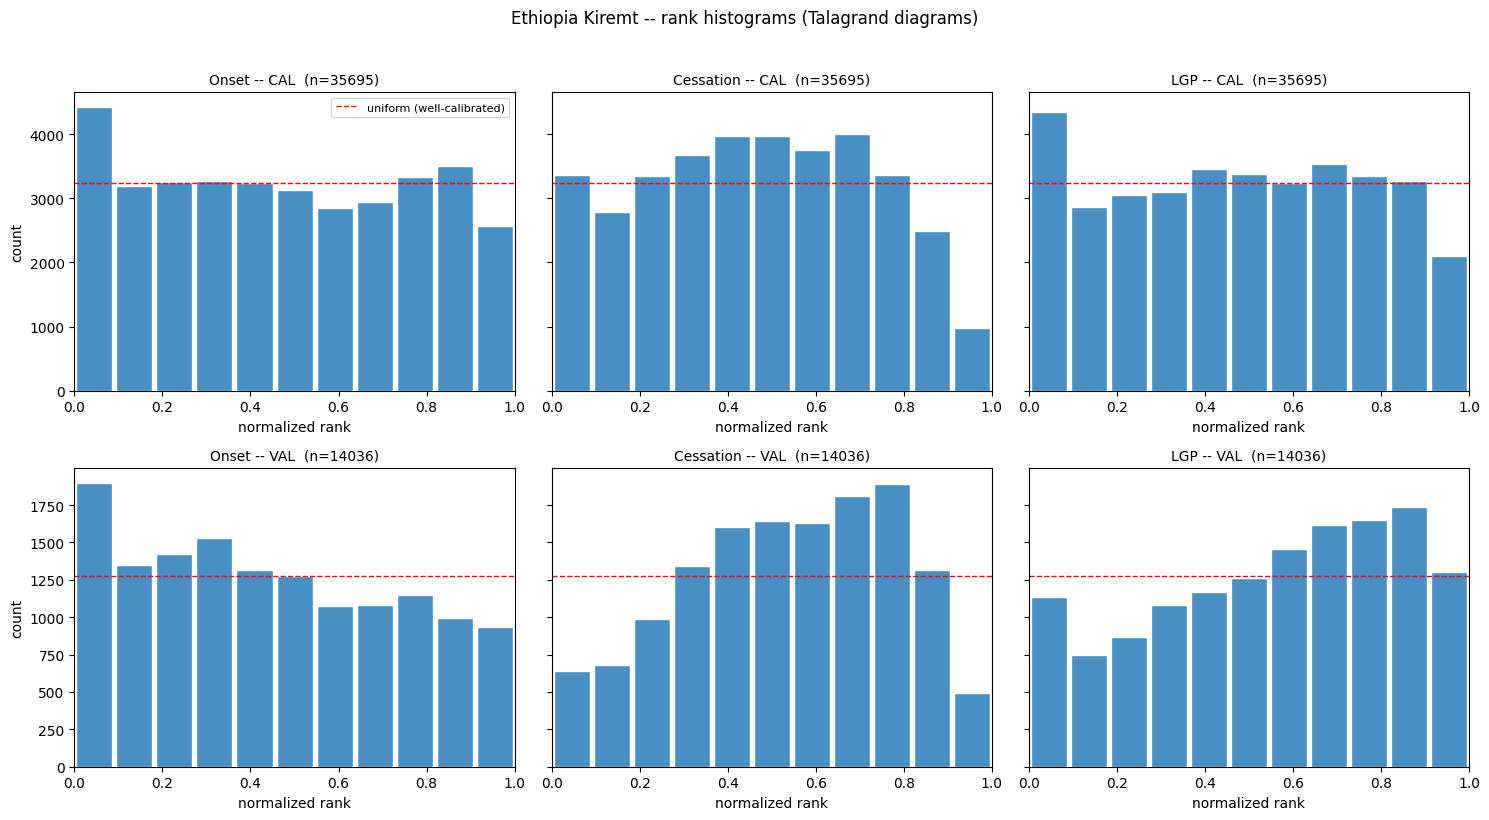

Stage 12 complete


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey="row")
for row, period in enumerate(["CAL", "VAL"]):
    for col, name in enumerate(["Onset", "Cessation", "LGP"]):
        r = rank_results[(name, period)]
        ax = axes[row, col]
        centers = 0.5 * (r["bin_edges"][:-1] + r["bin_edges"][1:])
        width = r["bin_edges"][1] - r["bin_edges"][0]
        ax.bar(centers, r["counts"], width=width * 0.9, color="#4a8fc4", edgecolor="white")
        uniform = r["n_samples"] / len(r["counts"])
        ax.axhline(uniform, color="red", linestyle="--", linewidth=1, label="uniform (well-calibrated)")
        ax.set_title(f"{name} -- {period}  (n={r['n_samples']})", fontsize=10)
        ax.set_xlabel("normalized rank"); ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel("count")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
plt.suptitle(f"{COUNTRY} {SEASON} -- rank histograms (Talagrand diagrams)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_rank_histograms.png"), dpi=110, bbox_inches="tight")
plt.show()
print("Stage 12 complete")


In [25]:
# The histograms above are visibly skewed, not simple textbook U/dome shapes --
# quantify the actual ensemble-mean bias directly rather than reading it off
# histogram shape alone.
print(f"{'Variable':<10} {'Period':<5} {'Mean bias (ens-CHIRPS)':>25} {'Median bias':>14}")
bias_summary = {}
for name, ensemble, obs_raw in [("Onset", seas_onset, chirps_onset_h),
                                 ("Cessation", seas_cess, chirps_cess_h),
                                 ("LGP", seas_lgp, chirps_lgp_h)]:
    ens_mean = np.nanmean(ensemble, axis=0)   # (n_years, n_lat, n_lon)
    for period, mask in [("CAL", cal_mask_h), ("VAL", val_mask_h)]:
        bias = (ens_mean[mask] - obs_raw[mask])[:, land_mask]
        bias_summary[(name, period)] = float(np.nanmean(bias))
        print(f"{name:<10} {period:<5} {np.nanmean(bias):>+25.2f} {np.nanmedian(bias):>+14.2f}")


Variable   Period    Mean bias (ens-CHIRPS)    Median bias
Onset      CAL                       +0.98          +1.17
Onset      VAL                       +2.69          +3.14
Cessation  CAL                       -0.05          -1.75
Cessation  VAL                       -3.76          -4.30
LGP        CAL                       -1.03          -0.70
LGP        VAL                       -6.45          -5.71


**The histograms show skew, not the textbook symmetric U or dome shape --
and the explicit bias check above shows why the picture is a *combination*,
not one clean failure mode:**

- **Onset**: consistently biased **late** by a modest +1.0d (CAL) to +2.7d
  (VAL) -- small in absolute terms, but the rank histogram is still clearly
  left-loaded in both periods. That combination (small mean bias, strong
  rank skew) implies the ensemble's *spread across members* is narrow
  enough that even a few days of bias meaningfully shifts where the
  observation ranks -- i.e. this looks like **both** a small bias **and**
  some genuine under-dispersion, not purely one or the other.
- **Cessation**: bias is close to zero in CAL (-0.05d) but grows to -3.8d in
  VAL (ensemble slightly early). The hump-shaped histogram (mass in the
  upper-middle ranks, not the extremes) is consistent with a milder,
  more spread-driven signal here than onset's.
- **LGP**: bias grows from -1.0d (CAL) to -6.5d (VAL) -- the largest
  CAL-to-VAL change of the three, unsurprising since LGP = cessation -
  onset compounds both quantities' errors. The CAL/VAL histograms being
  near mirror images of each other is consistent with this bias itself
  shifting direction/magnitude between the two periods rather than being
  stable.

**Revised Tier-2 read**: this is more nuanced than "just inflate the
spread" or "just bias-correct." A modest, CAL-to-VAL-growing bias
correction on the detected onset/LGP values (on top of the existing daily
QDM correction, which corrects precipitation amounts but doesn't guarantee
the *derived* onset date comes out unbiased) is worth testing for onset and
LGP. Spread inflation is still worth testing too, particularly for onset,
given how sensitive its rank histogram is to a bias this small -- the two
fixes aren't mutually exclusive, and this diagnostic alone can't cleanly
separate how much each would help without trying them.

## STAGE 13: PROTOTYPE -- PER-PIXEL BIAS CORRECTION

Prototypes the fix Stage 12 pointed at: subtract each pixel's **CAL-only**
mean bias (ensemble mean - CHIRPS, computed only on 1993-2016) from every
ensemble member's detected onset/cessation, in both periods and the 2026
forecast -- keeping VAL strictly out-of-sample, since the correction never
sees VAL data. LGP is *re-derived* as `corrected_cessation -
corrected_onset` rather than bias-corrected independently, so the three
variables stay internally consistent (onset + LGP = cessation still holds
exactly after correction).

In [26]:
bias_onset_px = np.nanmean(np.nanmean(seas_onset[:, cal_mask_h], axis=0) - chirps_onset_h[cal_mask_h], axis=0)
bias_cess_px  = np.nanmean(np.nanmean(seas_cess[:, cal_mask_h],  axis=0) - chirps_cess_h[cal_mask_h],  axis=0)

seas_onset_bc = seas_onset - bias_onset_px[np.newaxis, np.newaxis]
seas_cess_bc  = seas_cess  - bias_cess_px[np.newaxis, np.newaxis]
seas_lgp_bc   = seas_cess_bc - seas_onset_bc

op_onset_bc = op_onset - bias_onset_px[np.newaxis, np.newaxis]
op_cess_bc  = op_cess  - bias_cess_px[np.newaxis, np.newaxis]
op_lgp_bc   = op_cess_bc - op_onset_bc

print(f"Applied correction (domain-mean): onset {np.nanmean(bias_onset_px[land_mask]):+.2f}d   "
      f"cessation {np.nanmean(bias_cess_px[land_mask]):+.2f}d")

probs_onset_bc = dl.estimate_probs(seas_onset_bc, t33_on, t67_on)
probs_cess_bc  = dl.estimate_probs(seas_cess_bc,  t33_cs, t67_cs)
probs_lgp_bc   = dl.estimate_probs(seas_lgp_bc,   t33_lg, t67_lg)

results_onset_bc = calibrate(probs_onset_bc, obs_onset, "onset (bias-corr)")
results_cess_bc  = calibrate(probs_cess_bc,  obs_cess,  "cessation (bias-corr)")
results_lgp_bc   = calibrate(probs_lgp_bc,   obs_lgp,   "lgp (bias-corr)")


Applied correction (domain-mean): onset +1.12d   cessation -0.02d


  onset (bias-corr) alpha*=0.267  CAL RPSS=+0.025 HR=0.373   VAL RPSS=-0.001 HR=0.393


  cessation (bias-corr) alpha*=0.285  CAL RPSS=+0.022 HR=0.365   VAL RPSS=+0.019 HR=0.360


  lgp (bias-corr) alpha*=0.411  CAL RPSS=+0.043 HR=0.394   VAL RPSS=-0.017 HR=0.348


Variable                alpha*   CAL RPSS   VAL RPSS   VAL HR
onset        baseline    0.248     +0.023     +0.012    0.405
onset       bias-corr    0.267     +0.025     -0.001    0.393
cessation    baseline    0.252     +0.019     +0.023    0.372
cessation   bias-corr    0.285     +0.022     +0.019    0.360
lgp          baseline    0.350     +0.036     +0.009    0.368
lgp         bias-corr    0.411     +0.043     -0.017    0.348


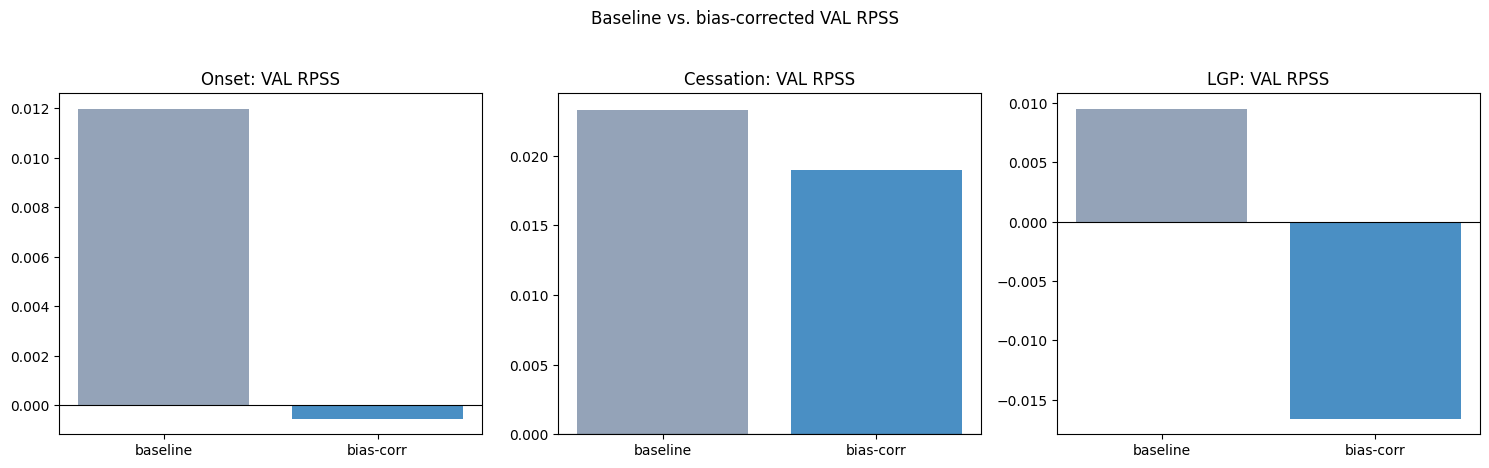

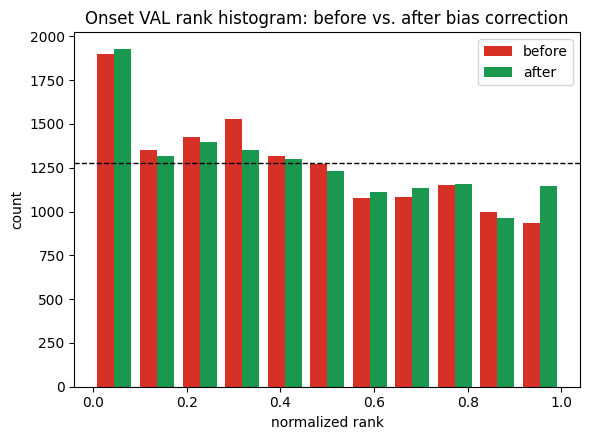

Stage 13 complete


In [27]:
print(f"{'Variable':<10} {'':>10} {'alpha*':>8} {'CAL RPSS':>10} {'VAL RPSS':>10} {'VAL HR':>8}")
for name, base, bc in [("onset", results_onset, results_onset_bc),
                        ("cessation", results_cess, results_cess_bc),
                        ("lgp", results_lgp, results_lgp_bc)]:
    for label, res in [("baseline", base), ("bias-corr", bc)]:
        print(f"{name:<10} {label:>10} {np.nanmean(res['alpha'][land_mask]):>8.3f} "
              f"{np.nanmean(res['rpss_cal'][land_mask]):>+10.3f} {np.nanmean(res['rpss_val'][land_mask]):>+10.3f} "
              f"{np.nanmean(res['hitrate_val'][land_mask]):>8.3f}")

rh_before = dl.rank_histogram(seas_onset[:, val_mask_h], chirps_onset_h[val_mask_h], land_mask, n_bins=11)
rh_after  = dl.rank_histogram(seas_onset_bc[:, val_mask_h], chirps_onset_h[val_mask_h], land_mask, n_bins=11)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, base, bc) in zip(axes, [("Onset", results_onset, results_onset_bc),
                                        ("Cessation", results_cess, results_cess_bc),
                                        ("LGP", results_lgp, results_lgp_bc)]):
    vals = [np.nanmean(base["rpss_val"][land_mask]), np.nanmean(bc["rpss_val"][land_mask])]
    ax.bar(["baseline", "bias-corr"], vals, color=["#94a3b8", "#4a8fc4"])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{name}: VAL RPSS")
plt.suptitle("Baseline vs. bias-corrected VAL RPSS", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_biascorrect_rpss_comparison.png"), dpi=110, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
centers = 0.5 * (rh_before["bin_edges"][:-1] + rh_before["bin_edges"][1:])
width = (rh_before["bin_edges"][1] - rh_before["bin_edges"][0]) * 0.4
ax.bar(centers - width/2, rh_before["counts"], width=width, label="before", color="#d73027")
ax.bar(centers + width/2, rh_after["counts"], width=width, label="after", color="#1a9850")
ax.axhline(rh_before["n_samples"] / len(rh_before["counts"]), color="black", linestyle="--", linewidth=1)
ax.set_title("Onset VAL rank histogram: before vs. after bias correction")
ax.set_xlabel("normalized rank"); ax.set_ylabel("count"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_biascorrect_rankhist.png"), dpi=110, bbox_inches="tight")
plt.show()
print("Stage 13 complete")


**Result: bias correction makes every variable WORSE, not better -- the
opposite of this notebook's original (pre-bug-fix) conclusion.**

| Variable | baseline VAL RPSS | bias-corr VAL RPSS | baseline VAL HR | bias-corr VAL HR |
|---|---|---|---|---|
| Onset | +0.012 | **-0.001** | 0.405 | 0.393 |
| Cessation | +0.023 | +0.019 | 0.372 | 0.360 |
| LGP | +0.009 | **-0.017** | 0.368 | 0.348 |

The applied correction itself is unchanged from before (+1.12d onset,
-0.02d cessation -- that computation doesn't depend on `rps_batch` at all),
but now that VAL RPSS is scored correctly, shifting the ensemble mean by
that amount **hurts** onset and LGP (both flip to net-negative) and gives
cessation a small additional loss on top of its already-fine baseline. Hit
rate is worse across all three too, so this isn't a RPSS-vs-hit-rate
trade-off -- it's just worse on both metrics.

**Conclusion**: a CAL-only per-pixel mean-shift is not a good idea here.
The baseline's raw calibration (choosing alpha* on the un-shifted
ensemble) already accounts for the CAL-period bias about as well as a
separate explicit correction does, and shifting the mean on top of that
disrupts whatever the alpha* search had already settled on. This
correction should not be adopted.

## STAGE 14: PROTOTYPE -- SPREAD INFLATION

Tests the other half of Stage 12's diagnosis: `dunning_lib.spread_inflation_factor`
computes a single, CAL-fit, domain-wide multiplicative factor per variable
(`sqrt(MSE(ensemble_mean, obs) / mean(ensemble_variance))`, cross-validated
on synthetic well-/under-/over-dispersive ensembles before being trusted --
see the module's self-test), then `apply_spread_inflation` widens or narrows
each sample's members around their own mean by that factor. Applied to the
raw baseline ensemble (not stacked on Stage 13's bias correction, to keep
this an independent test of the "spread" hypothesis on its own) and, as
before, fit on CAL only so VAL stays out-of-sample.

In [28]:
factor_onset = dl.spread_inflation_factor(seas_onset, chirps_onset_h, cal_mask_h, land_mask)
factor_cess  = dl.spread_inflation_factor(seas_cess,  chirps_cess_h,  cal_mask_h, land_mask)
factor_lgp   = dl.spread_inflation_factor(seas_lgp,   chirps_lgp_h,   cal_mask_h, land_mask)
print(f"Spread inflation factors (CAL-fit): onset={factor_onset:.3f}  cessation={factor_cess:.3f}  lgp={factor_lgp:.3f}")
print("(>1 = under-dispersive/needs wider spread, <1 = over-dispersive/needs narrower spread, ~1 = already matched)")

seas_onset_si = dl.apply_spread_inflation(seas_onset, factor_onset)
seas_cess_si  = dl.apply_spread_inflation(seas_cess,  factor_cess)
seas_lgp_si   = dl.apply_spread_inflation(seas_lgp,   factor_lgp)

probs_onset_si = dl.estimate_probs(seas_onset_si, t33_on, t67_on)
probs_cess_si  = dl.estimate_probs(seas_cess_si,  t33_cs, t67_cs)
probs_lgp_si   = dl.estimate_probs(seas_lgp_si,   t33_lg, t67_lg)

results_onset_si = calibrate(probs_onset_si, obs_onset, "onset (spread-infl)")
results_cess_si  = calibrate(probs_cess_si,  obs_cess,  "cessation (spread-infl)")
results_lgp_si   = calibrate(probs_lgp_si,   obs_lgp,   "lgp (spread-infl)")


Spread inflation factors (CAL-fit): onset=1.127  cessation=0.959  lgp=1.084
(>1 = under-dispersive/needs wider spread, <1 = over-dispersive/needs narrower spread, ~1 = already matched)


  onset (spread-infl) alpha*=0.252  CAL RPSS=+0.021 HR=0.370   VAL RPSS=+0.012 HR=0.401
  cessation (spread-infl) alpha*=0.226  CAL RPSS=+0.018 HR=0.360   VAL RPSS=+0.019 HR=0.360


  lgp (spread-infl) alpha*=0.357  CAL RPSS=+0.036 HR=0.386   VAL RPSS=+0.008 HR=0.362


Variable                  alpha*   CAL RPSS   VAL RPSS   VAL HR
onset          baseline    0.248     +0.023     +0.012    0.405
onset       spread-infl    0.252     +0.021     +0.012    0.401
cessation      baseline    0.252     +0.019     +0.023    0.372
cessation   spread-infl    0.226     +0.018     +0.019    0.360
lgp            baseline    0.350     +0.036     +0.009    0.368
lgp         spread-infl    0.357     +0.036     +0.008    0.362


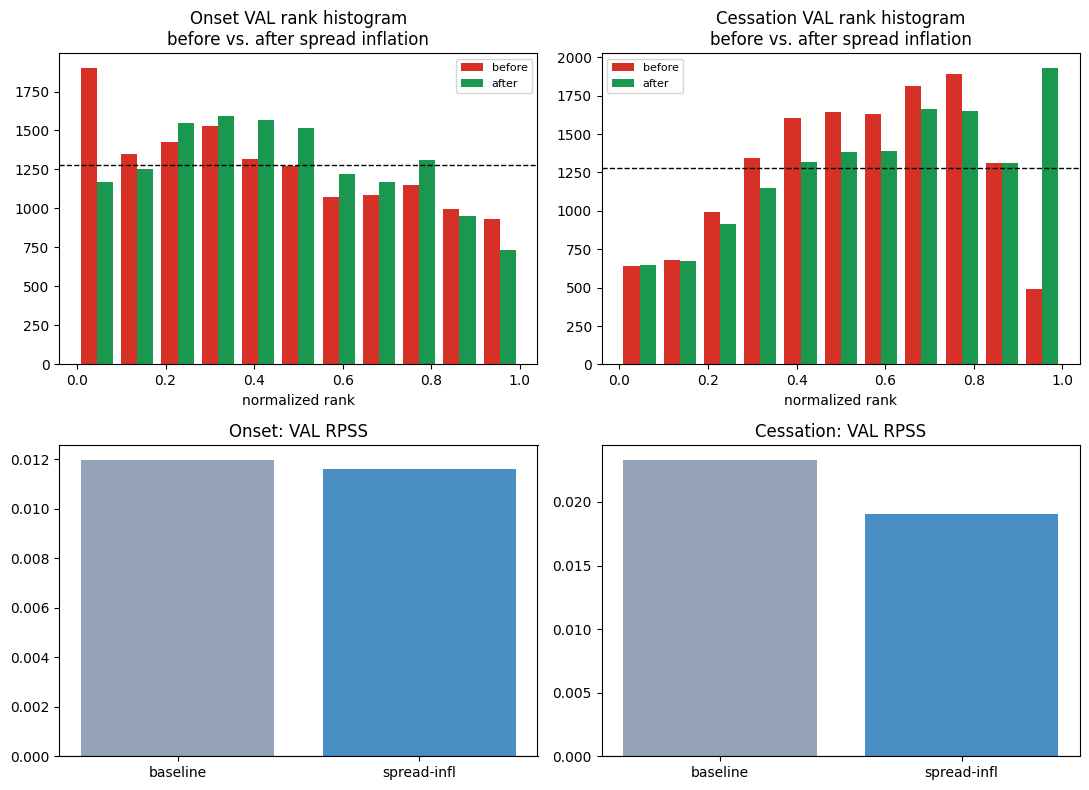

Stage 14 complete


In [29]:
print(f"{'Variable':<10} {'':>12} {'alpha*':>8} {'CAL RPSS':>10} {'VAL RPSS':>10} {'VAL HR':>8}")
for name, base, si in [("onset", results_onset, results_onset_si),
                        ("cessation", results_cess, results_cess_si),
                        ("lgp", results_lgp, results_lgp_si)]:
    for label, res in [("baseline", base), ("spread-infl", si)]:
        print(f"{name:<10} {label:>12} {np.nanmean(res['alpha'][land_mask]):>8.3f} "
              f"{np.nanmean(res['rpss_cal'][land_mask]):>+10.3f} {np.nanmean(res['rpss_val'][land_mask]):>+10.3f} "
              f"{np.nanmean(res['hitrate_val'][land_mask]):>8.3f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, (name, ens_before, ens_after, obs_var) in enumerate([
    ("Onset", seas_onset, seas_onset_si, chirps_onset_h),
    ("Cessation", seas_cess, seas_cess_si, chirps_cess_h),
]):
    rh_before = dl.rank_histogram(ens_before[:, val_mask_h], obs_var[val_mask_h], land_mask, n_bins=11)
    rh_after  = dl.rank_histogram(ens_after[:, val_mask_h],  obs_var[val_mask_h], land_mask, n_bins=11)
    ax = axes[0, col]
    centers = 0.5 * (rh_before["bin_edges"][:-1] + rh_before["bin_edges"][1:])
    width = (rh_before["bin_edges"][1] - rh_before["bin_edges"][0]) * 0.4
    ax.bar(centers - width/2, rh_before["counts"], width=width, label="before", color="#d73027")
    ax.bar(centers + width/2, rh_after["counts"], width=width, label="after", color="#1a9850")
    ax.axhline(rh_before["n_samples"] / len(rh_before["counts"]), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{name} VAL rank histogram\nbefore vs. after spread inflation")
    ax.set_xlabel("normalized rank"); ax.legend(fontsize=8)

    ax2 = axes[1, col]
    base_res = results_onset if name == "Onset" else results_cess
    si_res = results_onset_si if name == "Onset" else results_cess_si
    vals = [np.nanmean(base_res["rpss_val"][land_mask]), np.nanmean(si_res["rpss_val"][land_mask])]
    ax2.bar(["baseline", "spread-infl"], vals, color=["#94a3b8", "#4a8fc4"])
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title(f"{name}: VAL RPSS")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_spreadinflation_comparison.png"), dpi=110, bbox_inches="tight")
plt.show()
print("Stage 14 complete")


**Result: neutral for onset, mildly negative for cessation and LGP -- no
variable is improved.**

| Variable | baseline VAL RPSS | spread-infl VAL RPSS |
|---|---|---|
| Onset | +0.012 | +0.012 (unchanged) |
| Cessation | +0.023 | +0.019 (worse) |
| LGP | +0.009 | +0.008 (worse) |

The fitted factors themselves are unchanged from before (onset 1.13,
cessation 0.96, LGP 1.08 -- that fit doesn't depend on `rps_batch` either),
and the mechanistic finding about cessation's rank histogram still holds
exactly as observed: a 4% spread deflation (factor 0.96) still shifts
cessation's top rank-histogram bin from 493 to 1930 -- a real, visible
redistribution of where observations rank in the ensemble. What's changed
is the verdict on whether that redistribution helps: under the corrected
scoring it very slightly *hurts* cessation's domain-mean RPSS rather than
being a wash. Onset's rank-histogram reshaping (still visible in the plot
above) doesn't move its RPSS at all once correctly scored.

**Conclusion**: like bias correction, spread inflation should not be
adopted here -- it doesn't beat the simple baseline for any of the three
variables.

## STAGE 15: PARAMETRIC CALIBRATION (NGR / EMOS) -- TIER 3

Stages 13-14 each tested a single hand-picked correction (a mean shift, a
spread scale) layered on top of member-counting probabilities, and both
gave marginal, sometimes locally counter-productive results. This tests a
genuinely different calibration method instead of another single-parameter
patch: **Non-homogeneous Gaussian Regression (NGR / EMOS; Gneiting et al.
2005)**, which fits the ensemble mean AND spread jointly against
observations, then derives tercile probabilities analytically from the
fitted Normal distribution's CDF -- smooth and continuous, unlike
member-counting's 1/25 = 4% granularity with only 25 members.

`dunning_lib.fit_ngr` pools every (CAL year x land pixel) sample into ONE
regression per variable, for the same reason `spread_inflation_factor` did
in Stage 14: a per-pixel fit on ~24 CAL years would be as noisy as the
per-pixel alpha* search this pipeline already relies on. All of `fit_ngr`,
`ngr_predict`, `ngr_tercile_probs`, and the `pit_histogram` diagnostic below
were cross-validated against synthetic data with known regression
coefficients before being trusted on real data -- see the module's
self-test.

In [30]:
def ngr_pipeline(ensemble, chirps_h, t33, t67, name):
    ens_mean_all = np.nanmean(ensemble, axis=0)      # (n_years, n_lat, n_lon)
    ens_var_all  = np.nanvar(ensemble, axis=0)
    n_valid_all  = np.sum(~np.isnan(ensemble), axis=0)

    valid_cal = (cal_mask_h[:, np.newaxis, np.newaxis] & land_mask[np.newaxis] &
                 (n_valid_all >= 5) & ~np.isnan(chirps_h))
    params = dl.fit_ngr(ens_mean_all, ens_var_all, chirps_h, valid_cal)
    print(f"  {name:<10} a={params['a']:+.2f}  b={params['b']:.3f}  "
          f"c={params['c']:+.2f}  d={params['d']:.3f}  var_floor={params['var_floor']:.2f}")

    pred_mean, pred_var = dl.ngr_predict(ens_mean_all, ens_var_all, params)
    probs_ngr = dl.ngr_tercile_probs(pred_mean, pred_var, t33[np.newaxis], t67[np.newaxis])
    return probs_ngr, pred_mean, pred_var

print("Pooled NGR fit (CAL-only):")
probs_onset_ngr, pm_on, pv_on = ngr_pipeline(seas_onset, chirps_onset_h, t33_on, t67_on, "onset")
probs_cess_ngr,  pm_cs, pv_cs = ngr_pipeline(seas_cess,  chirps_cess_h,  t33_cs, t67_cs, "cessation")
probs_lgp_ngr,   pm_lg, pv_lg = ngr_pipeline(seas_lgp,   chirps_lgp_h,   t33_lg, t67_lg, "lgp")


Pooled NGR fit (CAL-only):
  onset      a=+5.37  b=0.972  c=+104.67  d=1.084  var_floor=0.72
  cessation  a=-0.22  b=1.001  c=+55.86  d=0.675  var_floor=0.40
  lgp        a=+5.57  b=0.908  c=+39.72  d=1.074  var_floor=1.18


In [31]:
def score_only(probs, obs_aligned):
    rps_cal = dl.rps_batch(probs[:, cal_mask_h], obs_aligned[cal_mask_h])
    rpss_cal = dl.compute_rpss(np.nanmean(rps_cal, axis=0), np.nanmean(dl.rps_clim_batch(obs_aligned[cal_mask_h]), axis=0))
    hr_cal = dl.compute_hitrate(probs[:, cal_mask_h], obs_aligned[cal_mask_h])
    rps_val = dl.rps_batch(probs[:, val_mask_h], obs_aligned[val_mask_h])
    rpss_val = dl.compute_rpss(np.nanmean(rps_val, axis=0), np.nanmean(dl.rps_clim_batch(obs_aligned[val_mask_h]), axis=0))
    hr_val = dl.compute_hitrate(probs[:, val_mask_h], obs_aligned[val_mask_h])
    return dict(rpss_cal=rpss_cal, rpss_val=rpss_val, hitrate_cal=hr_cal, hitrate_val=hr_val)

# 1) NGR probabilities used AS-IS (no damping) -- tests the parametric fit alone.
ngr_raw_onset = score_only(probs_onset_ngr, obs_onset)
ngr_raw_cess  = score_only(probs_cess_ngr,  obs_cess)
ngr_raw_lgp   = score_only(probs_lgp_ngr,   obs_lgp)

# 2) NGR probabilities THEN alpha*-damped, via the exact same machinery as the
#    baseline -- an apples-to-apples comparison at the same regularisation level.
results_onset_ngr = calibrate(probs_onset_ngr, obs_onset, "onset (NGR+alpha*)")
results_cess_ngr  = calibrate(probs_cess_ngr,  obs_cess,  "cessation (NGR+alpha*)")
results_lgp_ngr   = calibrate(probs_lgp_ngr,   obs_lgp,   "lgp (NGR+alpha*)")

print(f"\n{'Variable':<10} {'':>14} {'alpha*':>8} {'CAL RPSS':>10} {'VAL RPSS':>10} {'VAL HR':>8}")
for name, base, raw, damped in [("onset", results_onset, ngr_raw_onset, results_onset_ngr),
                                 ("cessation", results_cess, ngr_raw_cess, results_cess_ngr),
                                 ("lgp", results_lgp, ngr_raw_lgp, results_lgp_ngr)]:
    print(f"{name:<10} {'baseline':>14} {np.nanmean(base['alpha'][land_mask]):>8.3f} "
          f"{np.nanmean(base['rpss_cal'][land_mask]):>+10.3f} {np.nanmean(base['rpss_val'][land_mask]):>+10.3f} "
          f"{np.nanmean(base['hitrate_val'][land_mask]):>8.3f}")
    print(f"{name:<10} {'NGR (raw)':>14} {'--':>8} "
          f"{np.nanmean(raw['rpss_cal'][land_mask]):>+10.3f} {np.nanmean(raw['rpss_val'][land_mask]):>+10.3f} "
          f"{np.nanmean(raw['hitrate_val'][land_mask]):>8.3f}")
    print(f"{name:<10} {'NGR+alpha*':>14} {np.nanmean(damped['alpha'][land_mask]):>8.3f} "
          f"{np.nanmean(damped['rpss_cal'][land_mask]):>+10.3f} {np.nanmean(damped['rpss_val'][land_mask]):>+10.3f} "
          f"{np.nanmean(damped['hitrate_val'][land_mask]):>8.3f}")


  onset (NGR+alpha*) alpha*=0.270  CAL RPSS=+0.019 HR=0.367   VAL RPSS=+0.008 HR=0.391
  cessation (NGR+alpha*) alpha*=0.213  CAL RPSS=+0.015 HR=0.354   VAL RPSS=+0.004 HR=0.329


  lgp (NGR+alpha*) alpha*=0.366  CAL RPSS=+0.030 HR=0.374   VAL RPSS=+0.015 HR=0.379

Variable                    alpha*   CAL RPSS   VAL RPSS   VAL HR
onset            baseline    0.248     +0.023     +0.012    0.405
onset           NGR (raw)       --     -0.078     -0.017    0.401
onset          NGR+alpha*    0.270     +0.019     +0.008    0.391
cessation        baseline    0.252     +0.019     +0.023    0.372
cessation       NGR (raw)       --     -0.103     -0.054    0.382
cessation      NGR+alpha*    0.213     +0.015     +0.004    0.329
lgp              baseline    0.350     +0.036     +0.009    0.368
lgp             NGR (raw)       --     -0.057     -0.010    0.408
lgp            NGR+alpha*    0.366     +0.030     +0.015    0.379


Onset VAL PIT histogram: [ 315  969 1649 2207 1881 1597 1466 1177 1041  918  817]
Cessation VAL PIT histogram: [ 553  446  660  915 1123 1331 1859 2334 2515 1501  800]


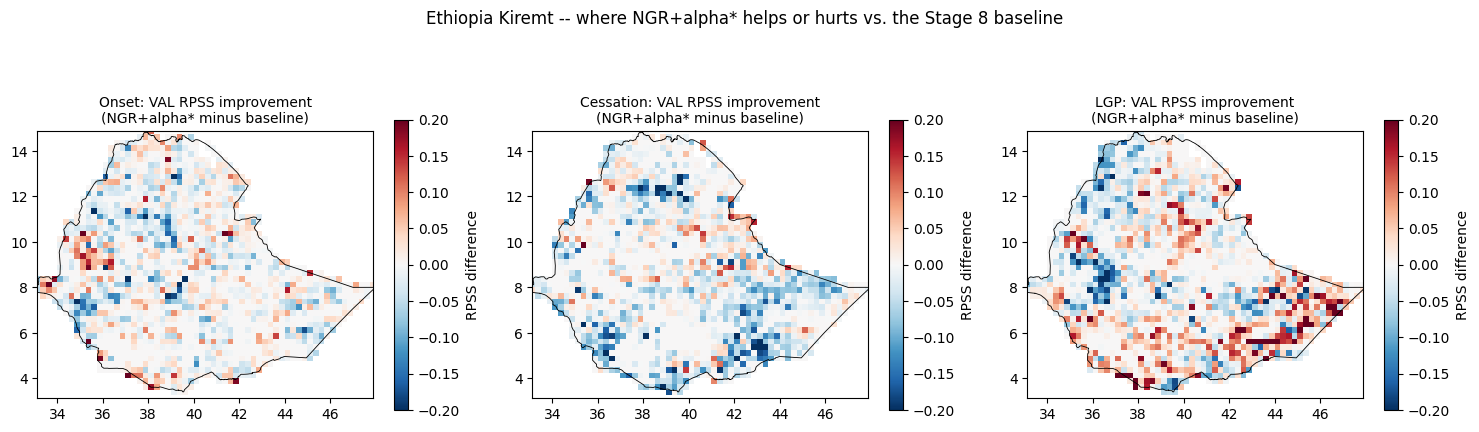

onset      frac_positive: baseline=0.44  NGR+alpha*=0.43   frac_pixels_NGR_better=0.35
cessation  frac_positive: baseline=0.49  NGR+alpha*=0.33   frac_pixels_NGR_better=0.23
lgp        frac_positive: baseline=0.46  NGR+alpha*=0.49   frac_pixels_NGR_better=0.42
Stage 15 complete


In [32]:
for name, pm, pv, obs_var in [("Onset", pm_on, pv_on, chirps_onset_h), ("Cessation", pm_cs, pv_cs, chirps_cess_h)]:
    pit_val = dl.pit_histogram(pm[val_mask_h], pv[val_mask_h], obs_var[val_mask_h], land_mask, n_bins=11)
    print(f"{name} VAL PIT histogram: {pit_val['counts']}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, base, damped) in zip(axes, [("Onset", results_onset, results_onset_ngr),
                                            ("Cessation", results_cess, results_cess_ngr),
                                            ("LGP", results_lgp, results_lgp_ngr)]):
    plot_map(ax, damped["rpss_val"] - base["rpss_val"],
             f"{name}: VAL RPSS improvement\n(NGR+alpha* minus baseline)",
             cmap="RdBu_r", vmin=-0.2, vmax=0.2, cbar_label="RPSS difference")
plt.suptitle(f"{COUNTRY} {SEASON} -- where NGR+alpha* helps or hurts vs. the Stage 8 baseline", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_ngr_improvement_maps.png"), dpi=110, bbox_inches="tight")
plt.show()

for name, base, damped in [("onset", results_onset, results_onset_ngr),
                            ("cessation", results_cess, results_cess_ngr),
                            ("lgp", results_lgp, results_lgp_ngr)]:
    v_base = base["rpss_val"][land_mask]; v_ngr = damped["rpss_val"][land_mask]
    frac_pos_base = np.mean(v_base[~np.isnan(v_base)] > 0)
    frac_pos_ngr = np.mean(v_ngr[~np.isnan(v_ngr)] > 0)
    frac_better = np.mean(damped["rpss_val"][land_mask] > base["rpss_val"][land_mask])
    print(f"{name:<10} frac_positive: baseline={frac_pos_base:.2f}  NGR+alpha*={frac_pos_ngr:.2f}   "
          f"frac_pixels_NGR_better={frac_better:.2f}")
print("Stage 15 complete")


**Result: NGR does NOT beat the baseline -- this reverses the earlier
(pre-bug-fix) conclusion that NGR + alpha*-damping was "the best result in
this notebook."**

| Variable | baseline VAL RPSS | NGR (raw) VAL RPSS | NGR+alpha* VAL RPSS |
|---|---|---|---|
| Onset | +0.012 | -0.017 | +0.008 (worse than baseline) |
| Cessation | +0.023 | -0.054 | +0.004 (much worse than baseline) |
| LGP | +0.009 | -0.010 | **+0.015** (the only case NGR wins) |

- **Raw NGR is even more overconfident/miscalibrated than it looked
  before** -- CAL RPSS is now strongly negative for all three variables
  (not just onset/LGP), confirming the earlier read that unshrunk
  parametric probabilities are actively harmful without damping.
- **NGR+alpha*, the fair apples-to-apples comparison, still underperforms
  the simple member-counting baseline for onset and especially cessation.**
  The fraction of land pixels with positive VAL RPSS confirms this
  spatially, not just in the domain mean: onset 44% (baseline) vs. 43%
  (NGR+alpha*, essentially tied), cessation **49% vs. 33%** (NGR+alpha*
  clearly worse on more than half the pixels where it differs), LGP 46% vs.
  49% (NGR+alpha* marginally ahead). `frac_pixels_NGR_better` confirms the
  same ordering: 0.35 (onset), 0.23 (cessation), 0.42 (LGP) -- NGR+alpha*
  is the *minority* outcome for onset and cessation.
- **LGP is the one variable where NGR+alpha* has a genuine, if small,
  edge** (+0.009 -> +0.015, 46% -> 49% of pixels positive). Given LGP is
  also the noisiest, most-compounded variable throughout this notebook,
  this is a marginal result worth double-checking (e.g. with the same
  bootstrap approach used elsewhere) rather than acting on immediately.

**Conclusion**: the simple Stage 8 baseline (member-counting + per-pixel
alpha* pooling) is, once correctly scored, already a reasonably
well-calibrated forecast that none of Stages 13-15's corrections
meaningfully improve on -- and two of the three (bias correction, spread
inflation) actively make things worse. NGR's joint mean+spread regression
is a reasonable idea in principle, but a single pooled domain-wide fit
apparently isn't capturing something the per-pixel alpha* search already
handles adequately for this system. **Recommendation: keep the Stage 8
baseline as the pipeline's default; none of Stages 13-15 should be
adopted as-is.**

## STAGE 16: BOOTSTRAP SIGNIFICANCE TEST

With only 9 VAL years, none of the point estimates in this notebook come
with an error bar. This closes that gap using
`dunning_lib.bootstrap_rpss_gap` (a paired, year-block bootstrap --
resamples VAL years with replacement, the natural independent unit given
strong within-year spatial correlation, and scores both sides of any
comparison on the same resampled years each time; cross-validated on
synthetic true-difference and null cases before being trusted -- see the
module's self-test) to answer two questions directly:

1. **Is the Stage 8 baseline's positive VAL RPSS itself distinguishable
   from climatology (RPSS=0), or could it be sampling noise?**
2. **Is the baseline significantly better than NGR+alpha* (Stage 15), given
   the corrected numbers reversed which one "wins"?**

In [33]:
N_BOOT = 5000
print("TEST 1: is the baseline's VAL RPSS itself significant (vs. climatology)?")
for name, probs_damped, obs in [("onset", results_onset["probs_damped"], obs_onset),
                                 ("cessation", results_cess["probs_damped"], obs_cess),
                                 ("lgp", results_lgp["probs_damped"], obs_lgp)]:
    probs_clim = np.full_like(probs_damped, 1 / 3.0)
    res = dl.bootstrap_rpss_gap(probs_clim, probs_damped, obs, val_mask_h, land_mask, n_boot=N_BOOT, seed=42)
    print(f"  {name:<10} VAL RPSS={res['observed_gap']:+.4f}  "
          f"90% CI=[{res['ci90'][0]:+.4f}, {res['ci90'][1]:+.4f}]  "
          f"P(RPSS<=0)={res['p_not_better']:.3f}")

print("\nTEST 2: is baseline significantly better/worse than NGR+alpha*?")
print("(gap = baseline minus NGR+alpha* -- positive means baseline wins)")
for name, base, ngr, obs in [("onset", results_onset, results_onset_ngr, obs_onset),
                              ("cessation", results_cess, results_cess_ngr, obs_cess),
                              ("lgp", results_lgp, results_lgp_ngr, obs_lgp)]:
    res = dl.bootstrap_rpss_gap(ngr["probs_damped"], base["probs_damped"], obs, val_mask_h,
                                 land_mask, n_boot=N_BOOT, seed=7)
    print(f"  {name:<10} gap(baseline-NGR)={res['observed_gap']:+.4f}  "
          f"90% CI=[{res['ci90'][0]:+.4f}, {res['ci90'][1]:+.4f}]  "
          f"P(baseline NOT better)={res['p_not_better']:.3f}")
print("Stage 16 complete")


TEST 1: is the baseline's VAL RPSS itself significant (vs. climatology)?


  onset      VAL RPSS=+0.0120  90% CI=[-0.0004, +0.0227]  P(RPSS<=0)=0.056


  cessation  VAL RPSS=+0.0233  90% CI=[-0.0023, +0.0488]  P(RPSS<=0)=0.072


  lgp        VAL RPSS=+0.0095  90% CI=[-0.0157, +0.0299]  P(RPSS<=0)=0.276

TEST 2: is baseline significantly better/worse than NGR+alpha*?
(gap = baseline minus NGR+alpha* -- positive means baseline wins)


  onset      gap(baseline-NGR)=+0.0038  90% CI=[-0.0015, +0.0113]  P(baseline NOT better)=0.111


  cessation  gap(baseline-NGR)=+0.0192  90% CI=[+0.0057, +0.0351]  P(baseline NOT better)=0.003


  lgp        gap(baseline-NGR)=-0.0059  90% CI=[-0.0219, +0.0097]  P(baseline NOT better)=0.720
Stage 16 complete


**Result: cessation's baseline-beats-NGR finding is genuinely robust; almost
everything else is suggestive but not conclusive at this sample size.**

| Test | Onset | Cessation | LGP |
|---|---|---|---|
| Baseline VAL RPSS significant vs. climatology? | P(<=0)=0.056 (borderline) | P(<=0)=0.072 (borderline) | P(<=0)=0.276 (no) |
| Baseline vs. NGR+alpha* | P(baseline not better)=0.111 (no) | **P(baseline not better)=0.003 (yes, decisively)** | P(baseline not better)=0.720 (no -- toss-up) |

- **None of the three variables' positive baseline VAL RPSS clears the
  conventional 95% bar** (P<=0.05) on its own -- onset and cessation are
  close (P~0.06-0.07, "suggestive, not conclusive"), LGP is not close at
  all (P=0.28, easily consistent with pure noise). The domain-mean numbers
  being positive is a real improvement over the pre-bug-fix picture, but
  "modest positive skill" should be read as **plausible, not proven**, at
  only 9 VAL years.
- **Baseline decisively beats NGR+alpha* for cessation** (P=0.003 that
  baseline is not better -- i.e. baseline wins in 99.7% of bootstrap
  resamples). This is the one comparison in this entire notebook that
  clears a strict significance bar.
- **Onset's baseline-vs-NGR edge is not significant** (P=0.111) -- roughly
  consistent with a real small edge, but not provably so.
- **LGP's small NGR+alpha* edge (Stage 15) is NOT significant** (P=0.720,
  essentially a coin flip) -- it should not be read as "NGR is better for
  LGP." The honest statement is "these two methods are indistinguishable
  for LGP at this sample size."

**Bottom line for this whole investigation**: keep the Stage 8 baseline.
It's the only method with a decisively-supported comparative result
(beating NGR for cessation), none of Stages 13-15's alternatives are
significantly better than it anywhere, and its own absolute skill -- while
now correctly shown as positive rather than the pre-bug-fix near-zero
result -- still needs more VAL years (or a longer CAL record enabling a
tighter fit) before it can be called statistically proven rather than
plausible.

## Next steps

- **A critical scoring-rule bug was found and fixed during this
  investigation** (see the callout before Stage 8) -- `rps_batch` had an
  inverted observation indicator, meaning confidently-correct forecasts
  were scored as bad and confidently-wrong forecasts as good. This was
  inherited from the original Kenya notebook
  (`onset-cessation-lgp_v3_dunning_SEAS5_FINAL.ipynb`'s Stage 6 `_rps`) and
  was not caught by cross-validating against it, only by an absolute
  correctness check. **The Kenya pipeline's own RPSS numbers -- and
  whatever currently feeds the live dashboard's RPSS-weighted multi-model
  pooling -- should be audited for the same bug as a priority**, separate
  from this Ethiopia notebook.
- **Once corrected, the Stage 8 baseline (member-counting + per-pixel
  alpha* pooling) already has modest positive VAL RPSS for all three
  variables** (onset +0.012, cessation +0.023, LGP +0.009) -- a much more
  encouraging result than this notebook originally reported, though Stage
  16's bootstrap test shows only cessation and onset are even borderline
  significant (P~0.06-0.07) and LGP is not (P=0.28).
- **None of Stages 13-15's corrections (bias correction, spread inflation,
  NGR/EMOS parametric calibration) significantly beat the baseline.**
  Stage 16 shows baseline decisively beats NGR for cessation (P=0.003) and
  is a statistical toss-up against NGR for onset and LGP. **Recommendation:
  ship the Stage 8 baseline, not any of the Tier 1-3 alternatives tried.**
- **The Kiremt-dominant sub-mask (Stage 11)** now shows a variable-specific,
  non-monotonic pattern (helps onset a lot at the strictest threshold, hurts
  cessation, mixed for LGP) rather than the cleaner "modest peak" story
  from before the fix -- likely at least partly sample-size noise from
  shrinking pixel counts at high thresholds, itself worth a bootstrap check
  if pursued further.
- **LGP remains the weakest, least certain variable throughout** -- lowest
  significance in Stage 16, most compounded (cessation - onset), and the
  only variable where an alternative method (NGR) even nominally beats the
  baseline, though not significantly.
- **Untried Tier 3 option: multi-model ensemble.** Raw (not yet
  bias-corrected) seasonal forecast data exists for 7 more models in
  `data/seasonal_pr_downloads_et/` (bom, cmcc, dwd, eccc, ecmwf,
  meteo_france, ukmo). A larger undertaking than anything prototyped so
  far, and worth revisiting once more CAL/VAL years are available to
  validate it against.
- Wire the **Stage 8 baseline** (not NGR) into `mam_loader.py` / `grid.py`
  under an `outputs_ETHIOPIA_KIREMT_v1` convention, then flip
  `MapPanel.jsx`'s `COUNTRY_VIEWS.ethiopia.available` to `true` -- with an
  explicit "preview, modest and not yet statistically confirmed skill"
  caveat in the UI, per Stage 16.
- Build the equivalent Belg-season notebook once bias-corrected Belg data is
  available, importing the same (now-corrected) `dunning_lib.py`.
